# Pengujian Model FFNN
## Dataset: Global Student Placement and Salary

Pengujian akan pengaruh berbagai hyperparameter terhadap model FFNN:
1. **Depth & Width**
2. **Fungsi Aktivasi** 
3. **Learning Rate** 
4. **Regularisasi** 
5. **Perbandingan sklearn MLP**
6. **Inisialisasi Bobot**
7. **RMSNorm (Normalisasi Hidden Layer)**
8. **Perbandingan Optimizer (SGD vs Adam)** 

---
## 0. Setup & Preprocessing

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')

from model import FFNN
from activation_function import ActivationFunctions
from loss_function import LossFunctions
from initialization import Initialization

np.random.seed(42)

In [2]:
# Load dataset
df = pd.read_csv('../data/datasetml_2026.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (10000, 12)
Columns: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [3]:
# Cek info dataset
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Target distribution:')
print(df['placement_status'].value_counts())

Data types:
cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
dtype: object

Missing values:
cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64

Target distribution:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


In [4]:
# Preprocessing

# Encode target
df['placement_status'] = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})

# One-hot encode kolom kategorikal
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {categorical_cols}')
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Pisahkan fitur dan target
X = df.drop('placement_status', axis=1).values.astype(np.float64)
y = df['placement_status'].values.astype(np.float64)

# One-hot encode target 
y_onehot = np.zeros((len(y), 2))
y_onehot[np.arange(len(y)), y.astype(int)] = 1

print(f'X shape: {X.shape}')
print(f'y_onehot shape: {y_onehot.shape}')

Categorical columns: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
X shape: (10000, 23)
y_onehot shape: (10000, 2)


In [5]:
# Normalisasi fitur 
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1 
X_norm = (X - X_min) / X_range

# Split train (Train: 70%, Validation: 15%, Test: 15%)
n = len(X_norm)
indices = np.random.permutation(n)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train = X_norm[indices[:train_end]]
y_train = y_onehot[indices[:train_end]]
X_val   = X_norm[indices[train_end:val_end]]
y_val   = y_onehot[indices[train_end:val_end]]
X_test  = X_norm[indices[val_end:]]
y_test  = y_onehot[indices[val_end:]]

n_features = X_train.shape[1]
n_classes = 2

print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')
print(f'Features: {n_features}, Classes: {n_classes}')

Train: 7000, Val: 1500, Test: 1500
Features: 23, Classes: 2


In [6]:
# Helper Function

# hitung akurasi
def accuracy(model, X, y_true):
    y_pred = model.predict(X)
    pred_labels = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_true, axis=1)
    return np.mean(pred_labels == true_labels)

# ringkasan eksperimen
def print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    train_acc = accuracy(model, X_train, y_train)
    val_acc = accuracy(model, X_val, y_val)
    test_acc = accuracy(model, X_test, y_test)
    print(f'{name}:')
    print(f'  Train Accuracy: {train_acc:.4f}')
    print(f'  Val Accuracy:   {val_acc:.4f}')
    print(f'  Test Accuracy:  {test_acc:.4f}')
    return {'name': name, 'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc}

# plot perbandingan loss
def compare_loss(models_dict, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for name, model in models_dict.items():
        ax1.plot(model.history['train_loss'], label=name)
        if model.history['val_loss']:
            ax2.plot(model.history['val_loss'], label=name)
    ax1.set_title(f'{title} (Training Loss)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.set_title(f'{title} (Validation Loss)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# plot perbandingan akurasi (bar chart)
def compare_accuracy_bar(results_list, title):
    names = [r['name'] for r in results_list]
    train_accs = [r['train_acc'] for r in results_list]
    val_accs = [r['val_acc'] for r in results_list]
    test_accs = [r['test_acc'] for r in results_list]
    
    x = np.arange(len(names))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, train_accs, width, label='Train', alpha=0.8)
    ax.bar(x, val_accs, width, label='Validation', alpha=0.8)
    ax.bar(x + width, test_accs, width, label='Test', alpha=0.8)
    ax.set_xlabel('Eksperimen')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

print('Helper functions loaded.')

Helper functions loaded.


---
## 1. Pengaruh Depth (Banyak Layer) dan Width (Banyak Neuron per Layer)

### 1a. Variasi Width (depth tetap = 3 hidden layers)

In [7]:
# Load model
import os
SAVE_DIR_WIDTH_MODELS = '../models/bab1a_width/'
width_models = {}
width_results = []
if os.path.exists(SAVE_DIR_WIDTH_MODELS):
    for f in sorted(os.listdir(SAVE_DIR_WIDTH_MODELS)):
        if f.endswith('.pkl'):
            name = f.replace('.pkl', '')
            width_models[name] = FFNN.load(os.path.join(SAVE_DIR_WIDTH_MODELS, f))
            print(f'  Loaded: {name}')
if width_models:
    print(f'\nBerhasil load {len(width_models)} model dari {SAVE_DIR_WIDTH_MODELS}')
    for name, model in width_models.items():
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        width_results.append(res)
else:
    print('Tidak ada model tersimpan, akan training dari awal.')

  Loaded: Width=128
  Loaded: Width=16
  Loaded: Width=64

Berhasil load 3 model dari ../models/bab1a_width/
Width=128:
  Train Accuracy: 0.8739
  Val Accuracy:   0.7260
  Test Accuracy:  0.7013
Width=16:
  Train Accuracy: 0.7807
  Val Accuracy:   0.7293
  Test Accuracy:  0.7260
Width=64:
  Train Accuracy: 0.8421
  Val Accuracy:   0.7207
  Test Accuracy:  0.7080


In [8]:
EPOCHS = 50
LR = 0.01
BATCH = 32

if not width_models:
    width_configs = {
        'Width=16':  [n_features, 16, 16, 16, n_classes],
        'Width=64':  [n_features, 64, 64, 64, n_classes],
        'Width=128': [n_features, 128, 128, 128, n_classes],
    }


    for name, sizes in width_configs.items():
        print(f'\n- Training {name}')
        n_hidden = len(sizes) - 2  # jumlah hidden layer
        acts = ['relu'] * n_hidden + ['softmax']

        model = FFNN(
            layer_sizes=sizes,
            activations=acts,
            loss='categorical_cross_entropy',
            init_method='he',
            init_params={'distribution': 'normal', 'seed': 42}
        )
        model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0, optimizer='adam')
        width_models[name] = model
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        width_results.append(res)
else:
    print('Model Bab 1a (Width) sudah di-load, skip training.')

Model Bab 1a (Width) sudah di-load, skip training.


In [9]:
# save model
import os
SAVE_DIR_WIDTH_MODELS = '../models/bab1a_width/'
os.makedirs(SAVE_DIR_WIDTH_MODELS, exist_ok=True)
for name, model in width_models.items():
    model.save(os.path.join(SAVE_DIR_WIDTH_MODELS, f'{name}.pkl'))
    print(f'  Saved: {name}')
print(f'Semua model Bab 1a (Width) disimpan di {SAVE_DIR_WIDTH_MODELS}')

  Saved: Width=128
  Saved: Width=16
  Saved: Width=64
Semua model Bab 1a (Width) disimpan di ../models/bab1a_width/


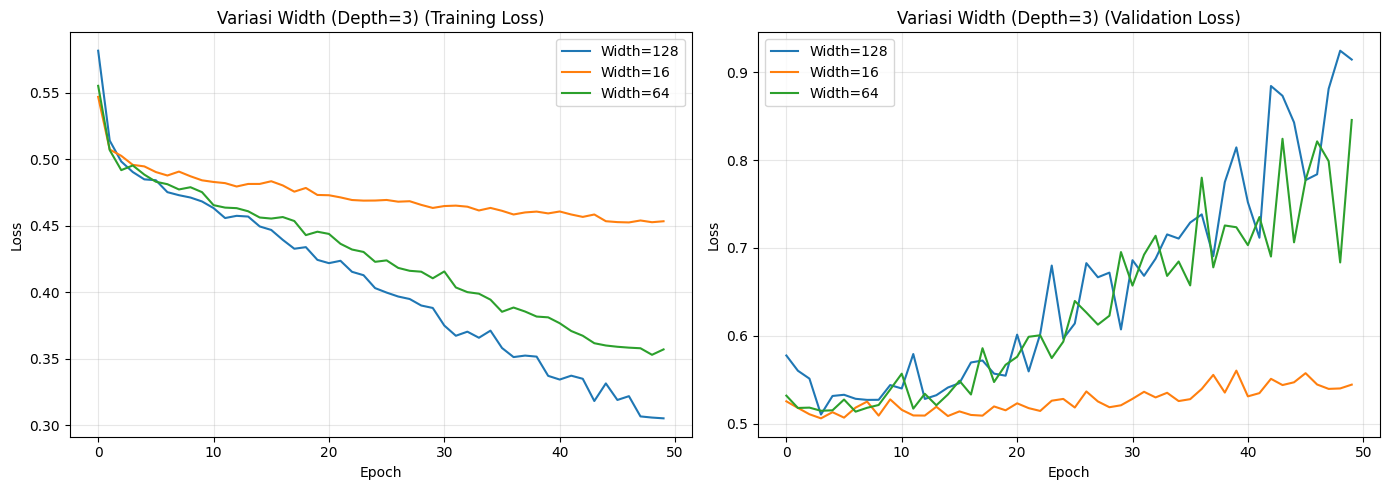

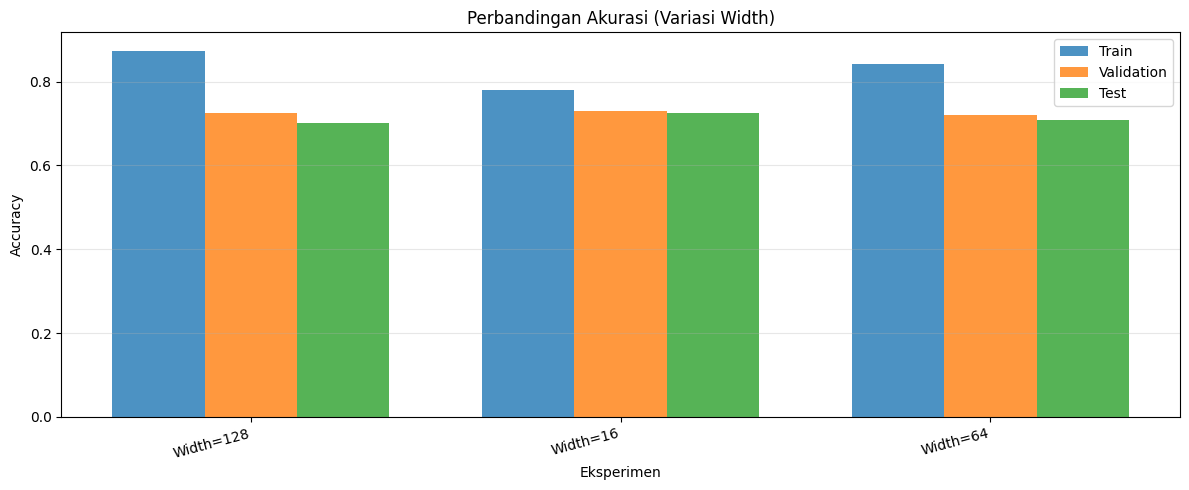

In [10]:
# Perbandingan loss dan akurasi
compare_loss(width_models, 'Variasi Width (Depth=3)')
compare_accuracy_bar(width_results, 'Perbandingan Akurasi (Variasi Width)')

### 1b. Variasi Depth (width tetap = 64 per hidden layer)

In [11]:
# load model 
import os
SAVE_DIR_DEPTH_MODELS = '../models/bab1b_depth/'
depth_models = {}
depth_results = []
if os.path.exists(SAVE_DIR_DEPTH_MODELS):
    for f in sorted(os.listdir(SAVE_DIR_DEPTH_MODELS)):
        if f.endswith('.pkl'):
            name = f.replace('.pkl', '')
            depth_models[name] = FFNN.load(os.path.join(SAVE_DIR_DEPTH_MODELS, f))
            print(f'  Loaded: {name}')
if depth_models:
    print(f'\nBerhasil load {len(depth_models)} model dari {SAVE_DIR_DEPTH_MODELS}')
    for name, model in depth_models.items():
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        depth_results.append(res)
else:
    print('Tidak ada model tersimpan, akan training dari awal.')

  Loaded: Depth=1
  Loaded: Depth=3
  Loaded: Depth=5

Berhasil load 3 model dari ../models/bab1b_depth/
Depth=1:
  Train Accuracy: 0.8163
  Val Accuracy:   0.7247
  Test Accuracy:  0.7133
Depth=3:
  Train Accuracy: 0.8256
  Val Accuracy:   0.7207
  Test Accuracy:  0.7007
Depth=5:
  Train Accuracy: 0.8104
  Val Accuracy:   0.7327
  Test Accuracy:  0.7140


In [12]:
if not depth_models:
    depth_configs = {
        'Depth=1': [n_features, 64, n_classes],
        'Depth=3': [n_features, 64, 64, 64, n_classes],
        'Depth=5': [n_features, 64, 64, 64, 64, 64, n_classes],
    }

    for name, sizes in depth_configs.items():
        print(f'\n- Training {name}')
        n_hidden = len(sizes) - 2
        acts = ['relu'] * n_hidden + ['softmax']

        model = FFNN(
            layer_sizes=sizes,
            activations=acts,
            loss='categorical_cross_entropy',
            init_method='he',
            init_params={'distribution': 'normal', 'seed': 42}
        )
        model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0, optimizer='adam')
        depth_models[name] = model
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        depth_results.append(res)
else:
    print('Model Bab 1b (Depth) sudah di-load, skip training.')

Model Bab 1b (Depth) sudah di-load, skip training.


In [13]:
# save model
import os
SAVE_DIR_DEPTH_MODELS = '../models/bab1b_depth/'
os.makedirs(SAVE_DIR_DEPTH_MODELS, exist_ok=True)
for name, model in depth_models.items():
    model.save(os.path.join(SAVE_DIR_DEPTH_MODELS, f'{name}.pkl'))
    print(f'  Saved: {name}')
print(f'Semua model Bab 1b (Depth) disimpan di {SAVE_DIR_DEPTH_MODELS}')

  Saved: Depth=1
  Saved: Depth=3
  Saved: Depth=5
Semua model Bab 1b (Depth) disimpan di ../models/bab1b_depth/


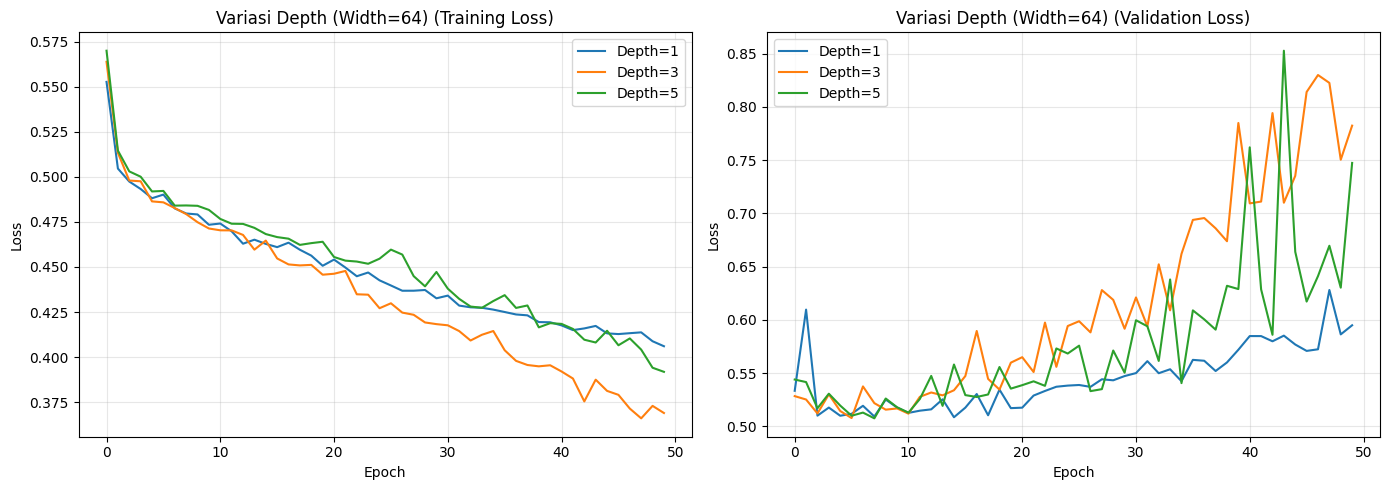

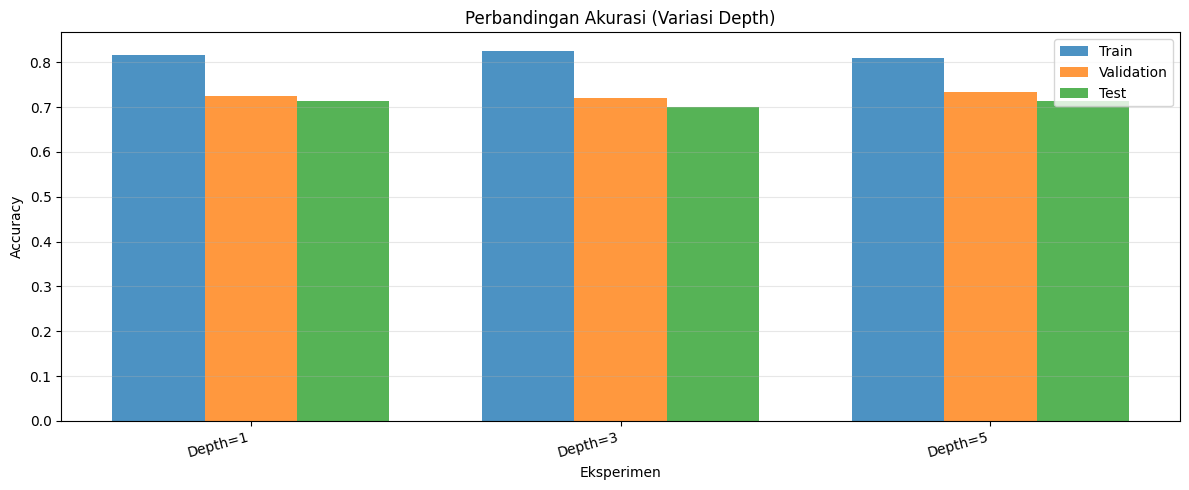

In [14]:
# perbandingan loss dan akurasi
compare_loss(depth_models, 'Variasi Depth (Width=64)')
compare_accuracy_bar(depth_results, 'Perbandingan Akurasi (Variasi Depth)')

---
## 2. Pengaruh Fungsi Aktivasi Hidden Layer
**Base arsitektur:** 4 layer  
**Layer pengetesan:** Layer ke-2 (hidden layer tengah)  
**Variasi fungsi aktivasi yang diuji:** linear, relu, sigmoid, tanh, elu, swish (semua kecuali softmax)

In [15]:
# load model 
import os
SAVE_DIR_ACT_MODELS = '../models/bab2_activation/'
act_models = {}
act_results = []
if os.path.exists(SAVE_DIR_ACT_MODELS):
    for f in sorted(os.listdir(SAVE_DIR_ACT_MODELS)):
        if f.endswith('.pkl'):
            name = f.replace('.pkl', '')
            act_models[name] = FFNN.load(os.path.join(SAVE_DIR_ACT_MODELS, f))
            print(f'  Loaded: {name}')
if act_models:
    print(f'\nBerhasil load {len(act_models)} model dari {SAVE_DIR_ACT_MODELS}')
    for name, model in act_models.items():
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        act_results.append(res)
else:
    print('Tidak ada model tersimpan, akan training dari awal.')

  Loaded: elu
  Loaded: linear
  Loaded: relu
  Loaded: sigmoid
  Loaded: swish
  Loaded: tanh

Berhasil load 6 model dari ../models/bab2_activation/
elu:
  Train Accuracy: 0.8164
  Val Accuracy:   0.7320
  Test Accuracy:  0.7087
linear:
  Train Accuracy: 0.8069
  Val Accuracy:   0.7300
  Test Accuracy:  0.7153
relu:
  Train Accuracy: 0.8541
  Val Accuracy:   0.7007
  Test Accuracy:  0.7120
sigmoid:
  Train Accuracy: 0.8590
  Val Accuracy:   0.7053
  Test Accuracy:  0.6813
swish:
  Train Accuracy: 0.8293
  Val Accuracy:   0.7020
  Test Accuracy:  0.6807
tanh:
  Train Accuracy: 0.8251
  Val Accuracy:   0.6980
  Test Accuracy:  0.6893


In [16]:
if not act_models:
    activation_names = ['linear', 'relu', 'sigmoid', 'tanh', 'elu', 'swish']


    for act_name in activation_names:
        print(f'\n- Aktivasi: {act_name}')
        # Layer 1: relu, Layer 2: variasi, Layer 3: relu, Output: softmax
        acts = ['relu', act_name, 'relu', 'softmax']

        model = FFNN(
            layer_sizes=[n_features, 64, 64, 64, n_classes],
            activations=acts,
            loss='categorical_cross_entropy',
            init_method='he',
            init_params={'distribution': 'normal', 'seed': 42}
        )
        model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0, optimizer='adam')
        act_models[act_name] = model
        res = print_results(act_name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        act_results.append(res)
else:
    print('Model Bab 2 (Aktivasi) sudah di-load, skip training.')

Model Bab 2 (Aktivasi) sudah di-load, skip training.


In [17]:
# save model
import os
SAVE_DIR_ACT_MODELS = '../models/bab2_activation/'
os.makedirs(SAVE_DIR_ACT_MODELS, exist_ok=True)
for name, model in act_models.items():
    model.save(os.path.join(SAVE_DIR_ACT_MODELS, f'{name}.pkl'))
    print(f'  Saved: {name}')
print(f'Semua model Bab 2 (Aktivasi) disimpan di {SAVE_DIR_ACT_MODELS}')

  Saved: elu
  Saved: linear
  Saved: relu
  Saved: sigmoid
  Saved: swish
  Saved: tanh
Semua model Bab 2 (Aktivasi) disimpan di ../models/bab2_activation/


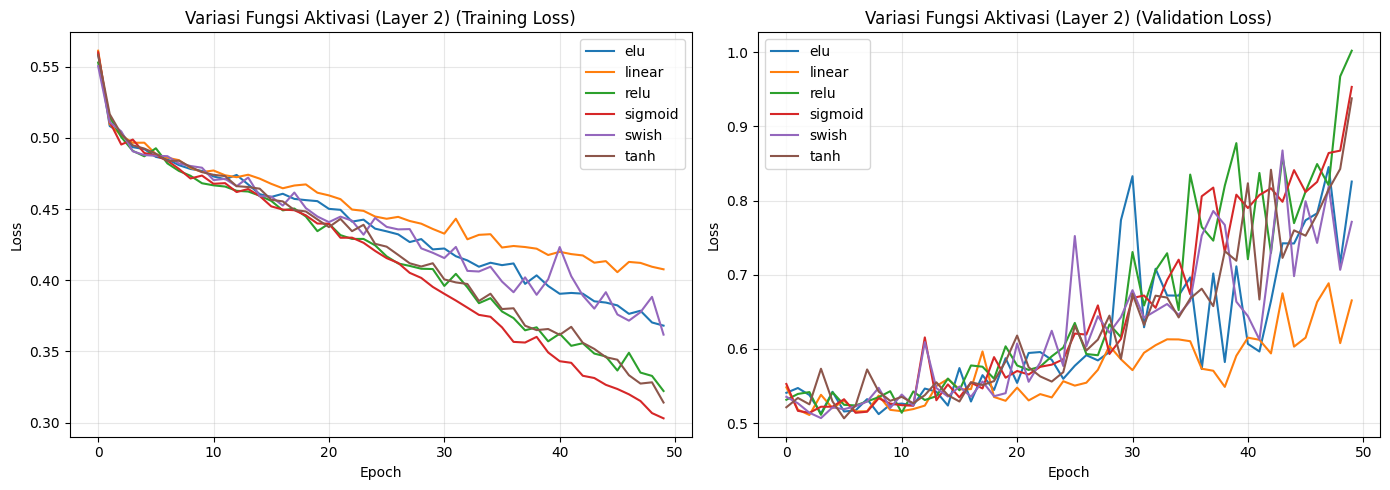

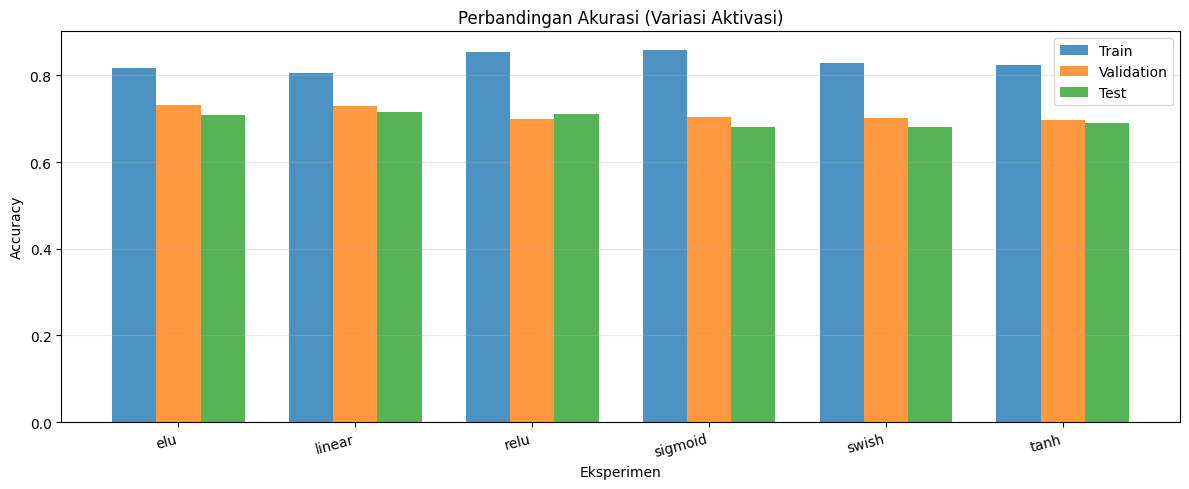

In [18]:
# Perbandingan loss dan akurasi
compare_loss(act_models, 'Variasi Fungsi Aktivasi (Layer 2)')
compare_accuracy_bar(act_results, 'Perbandingan Akurasi (Variasi Aktivasi)')


- Aktivasi: elu


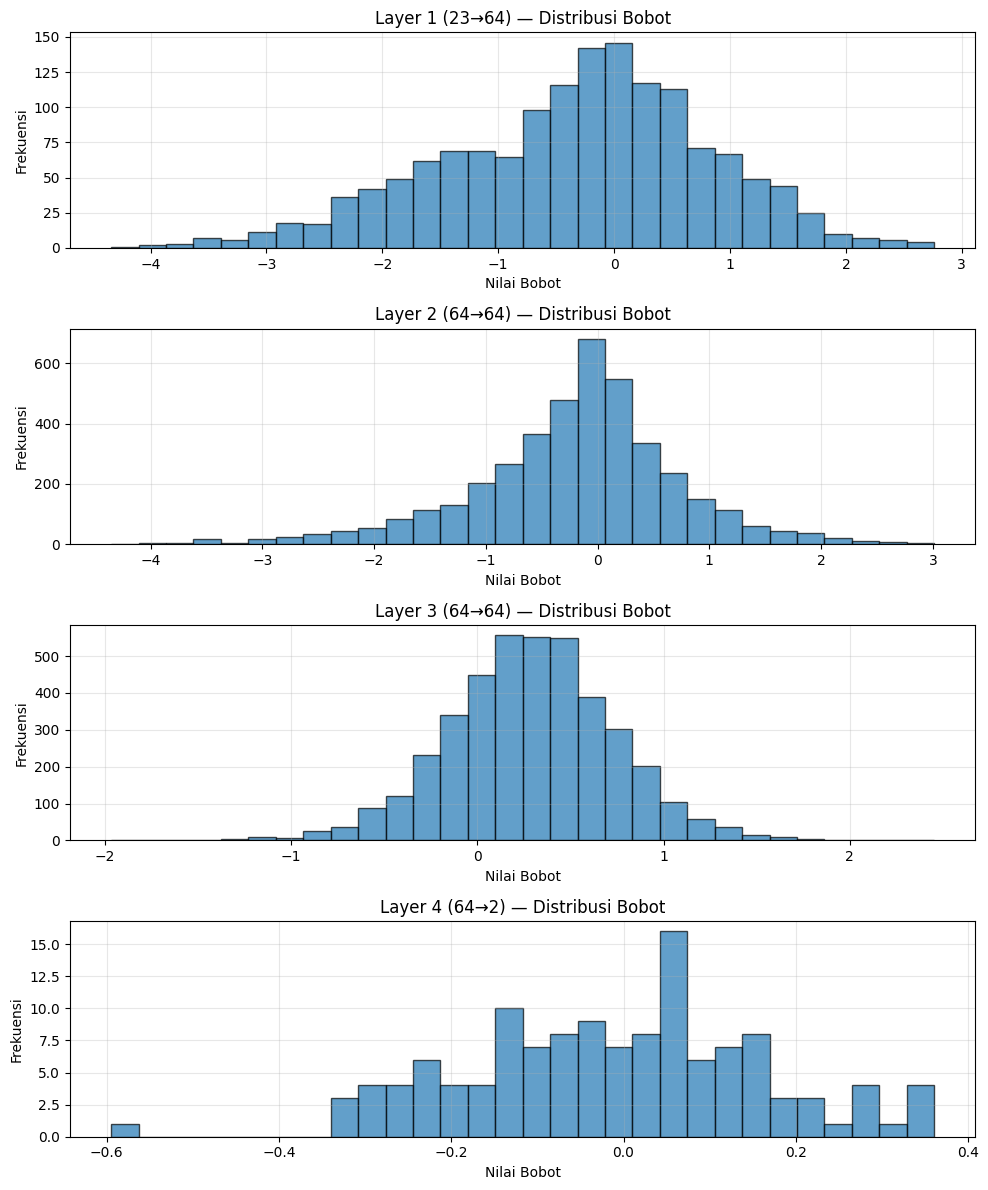

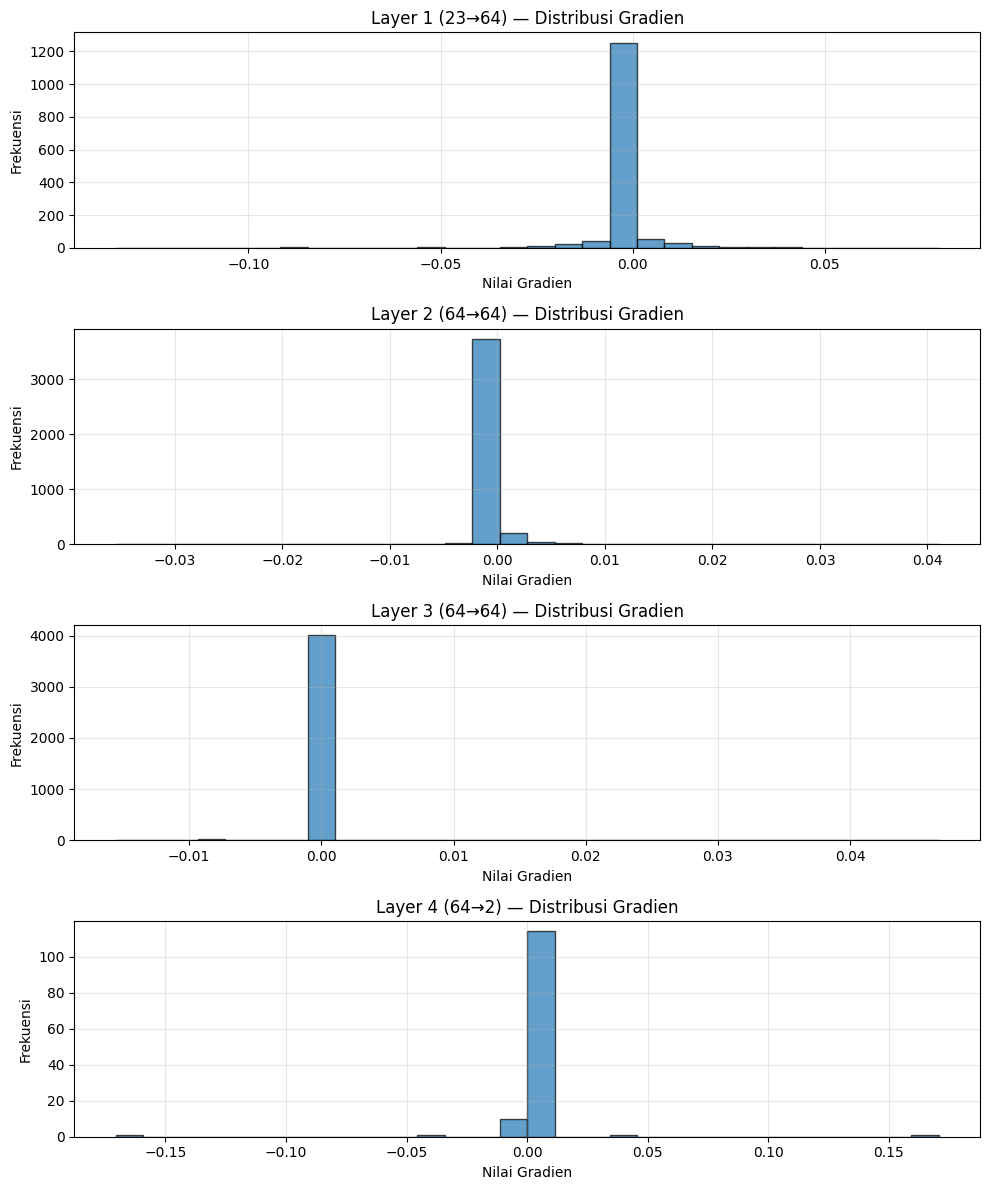


- Aktivasi: linear


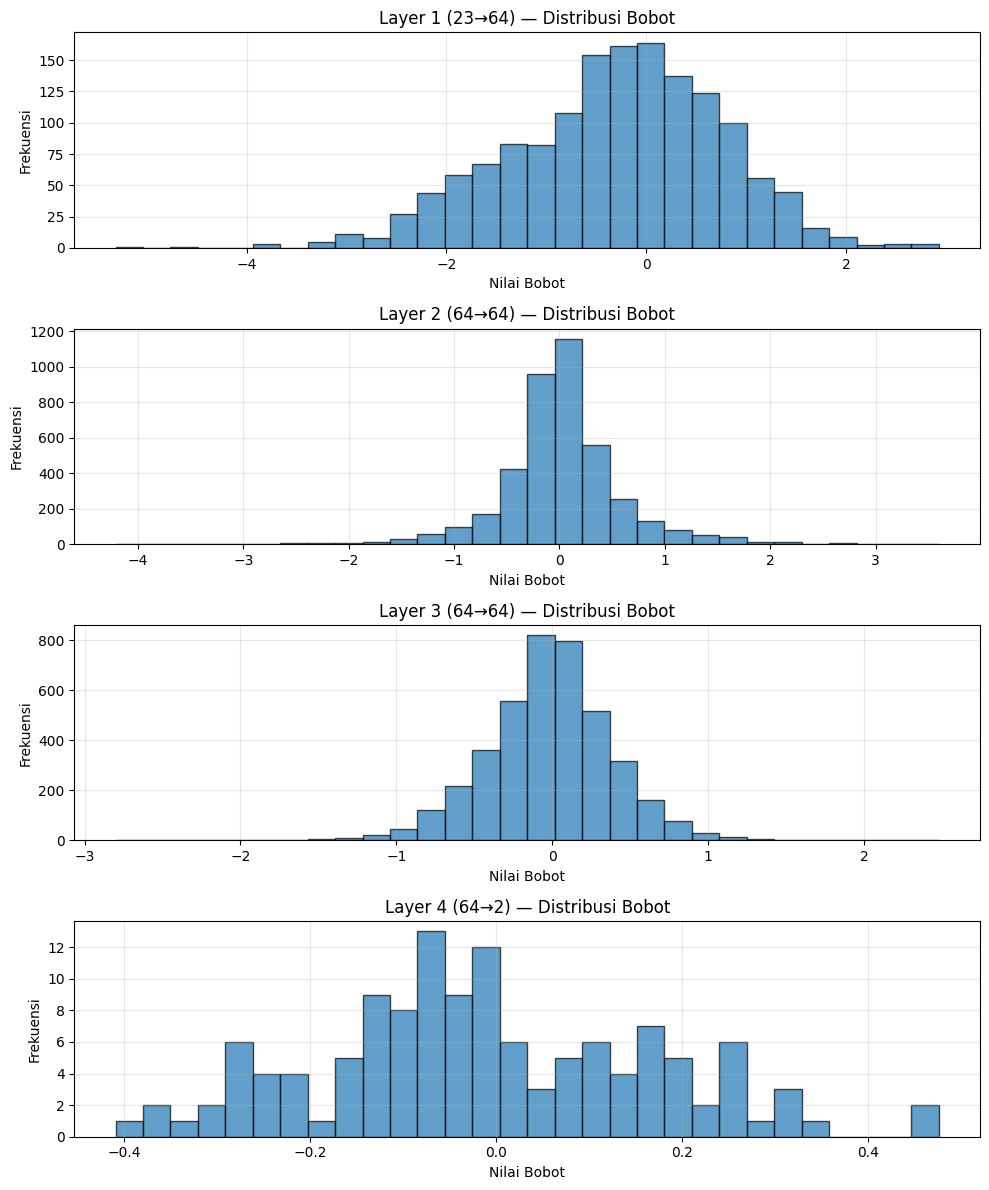

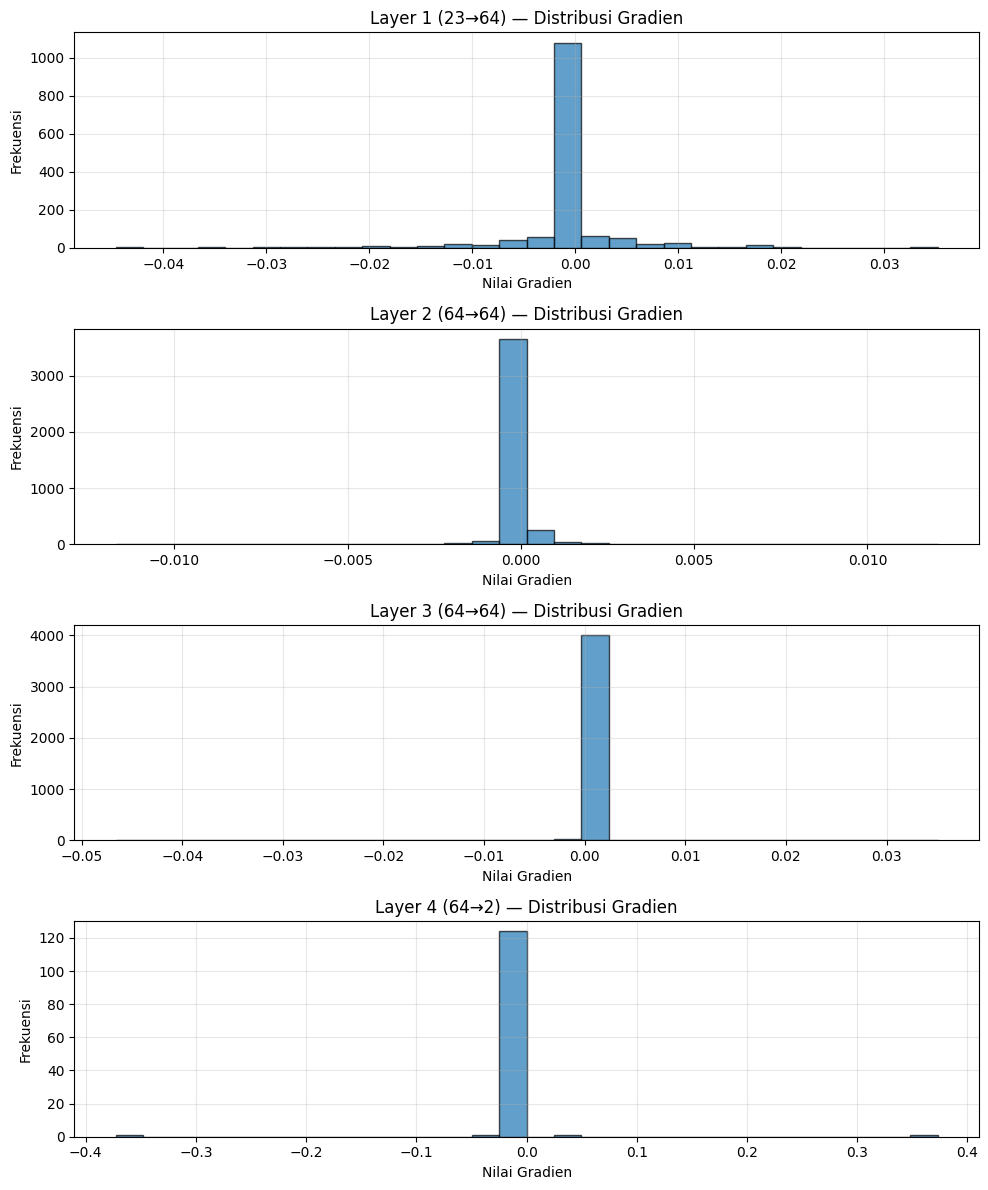


- Aktivasi: relu


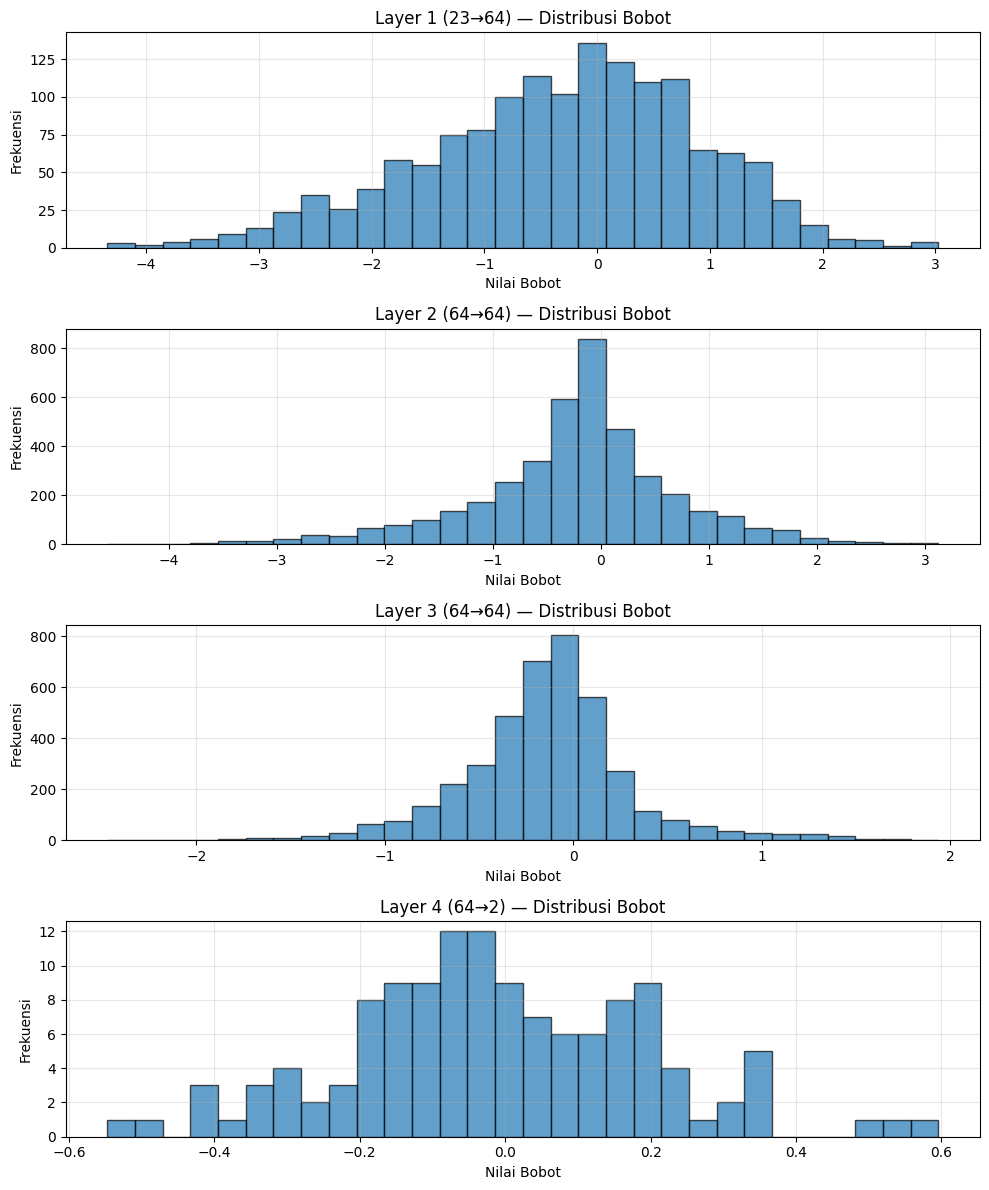

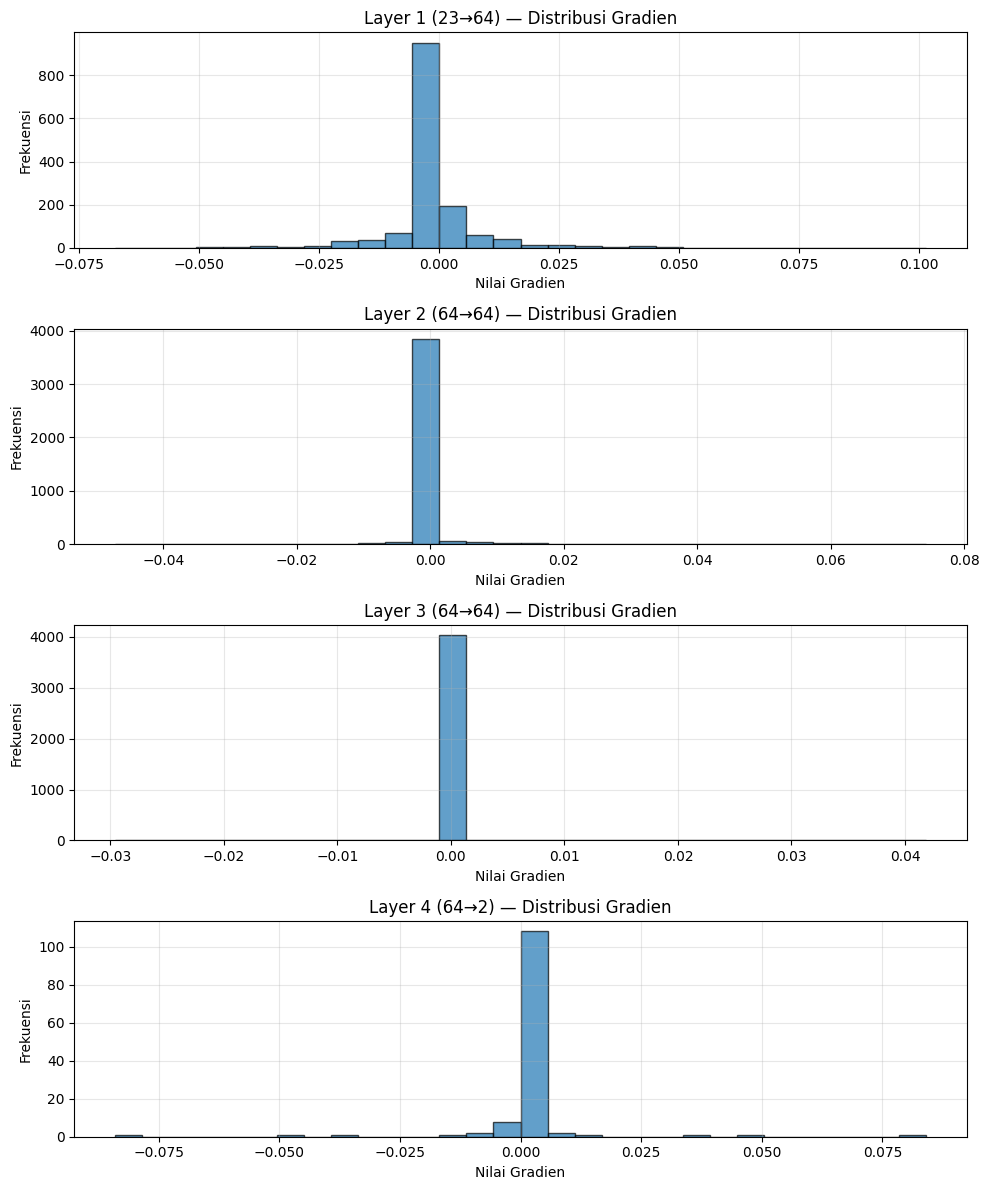


- Aktivasi: sigmoid


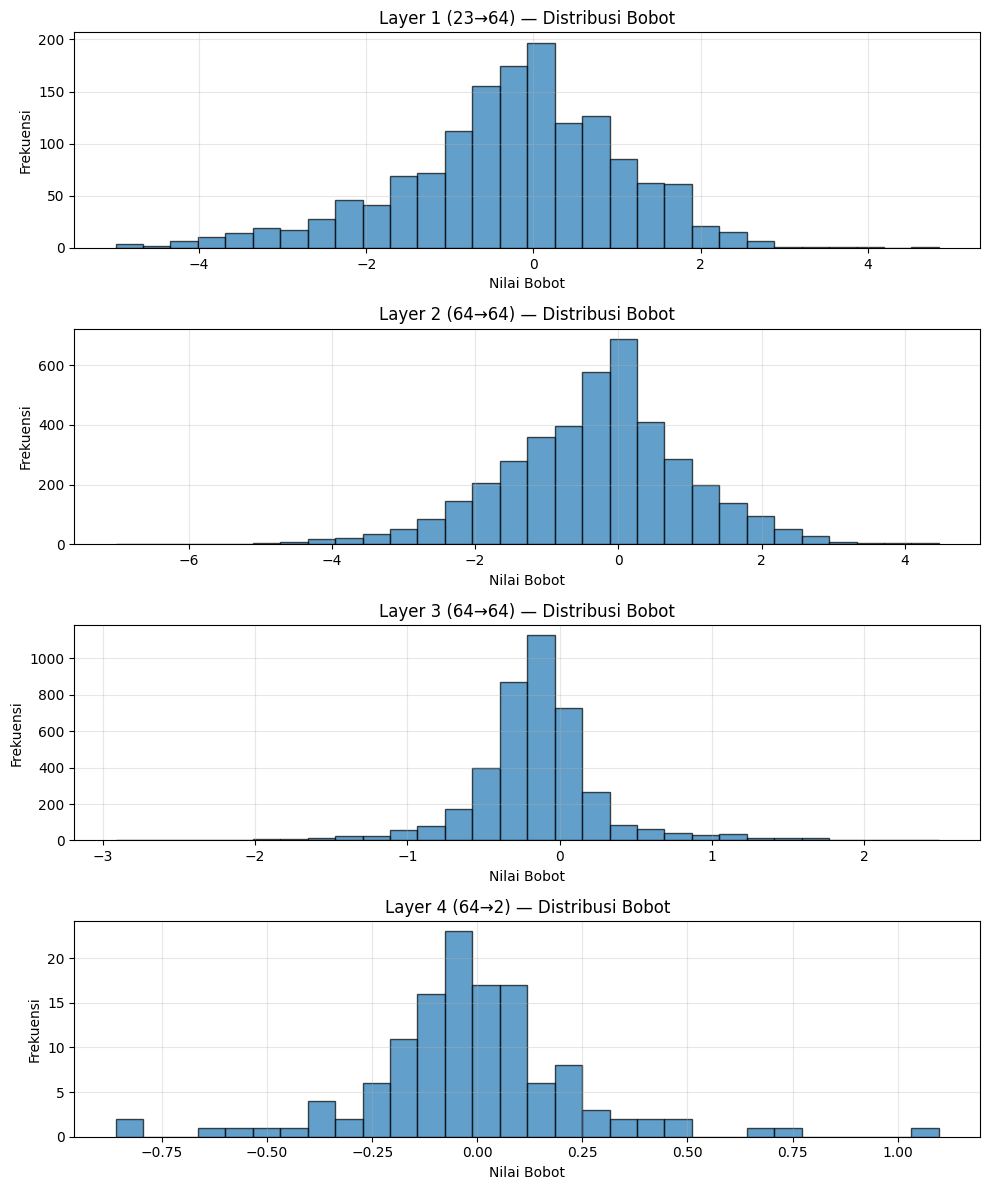

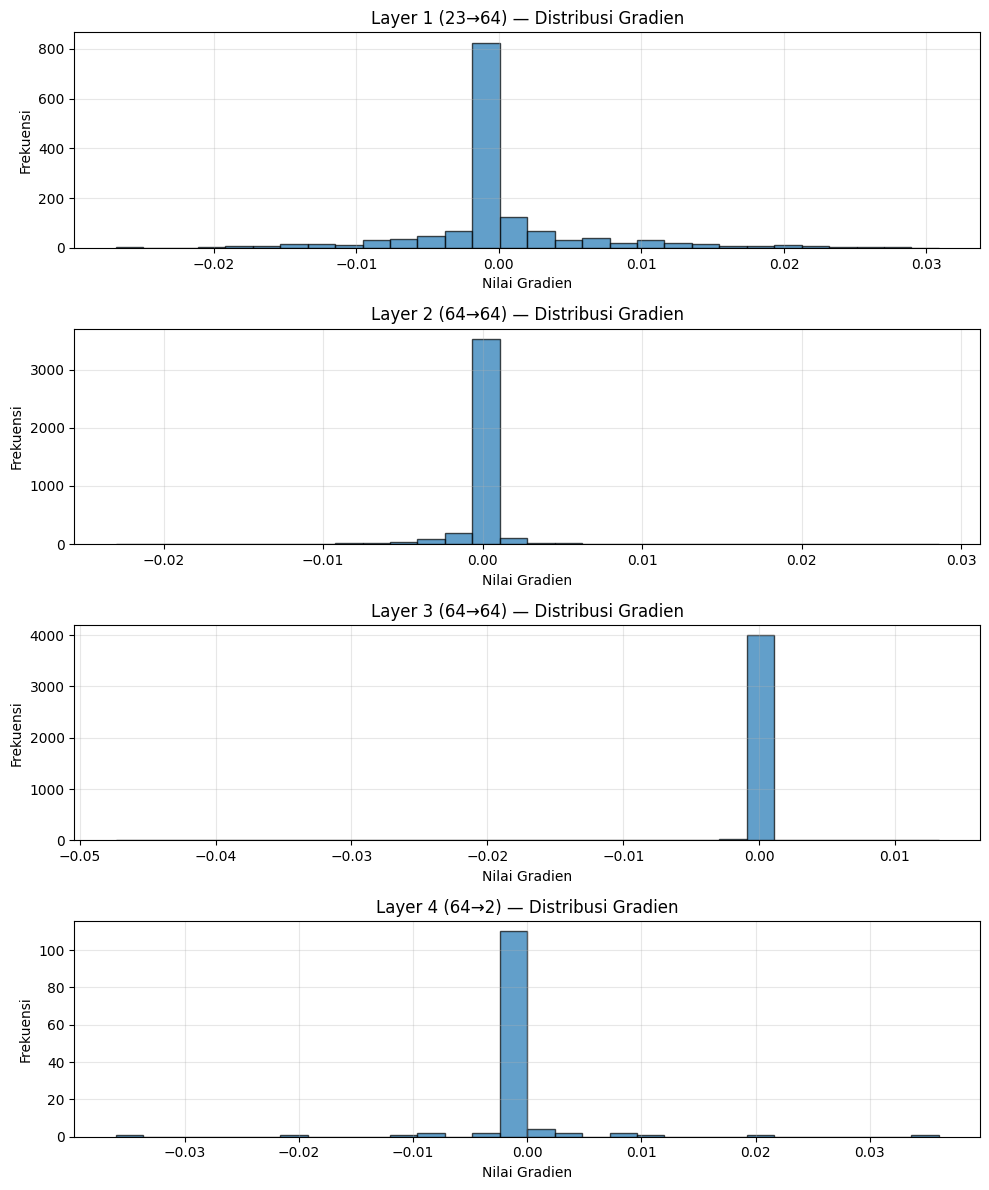


- Aktivasi: swish


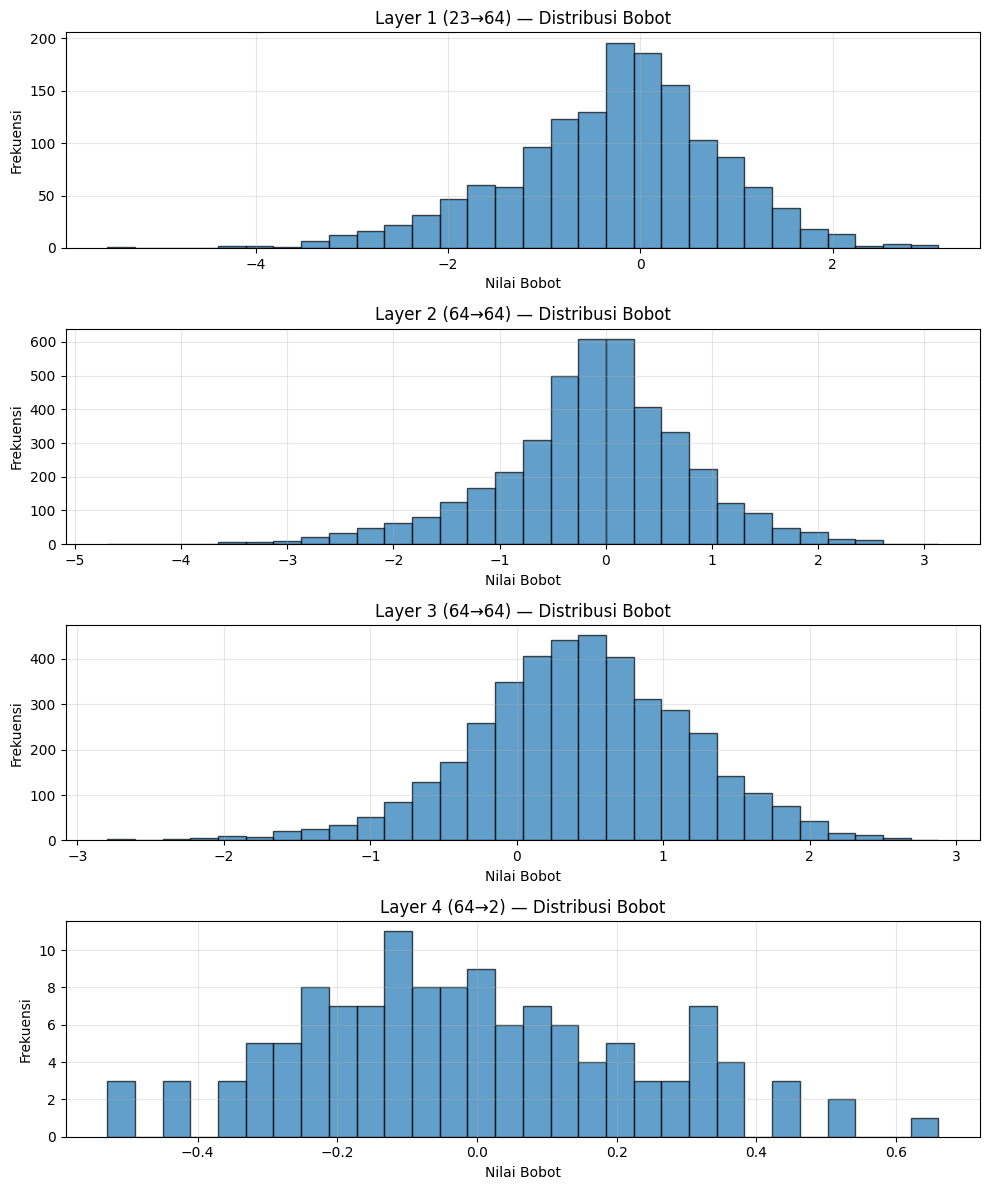

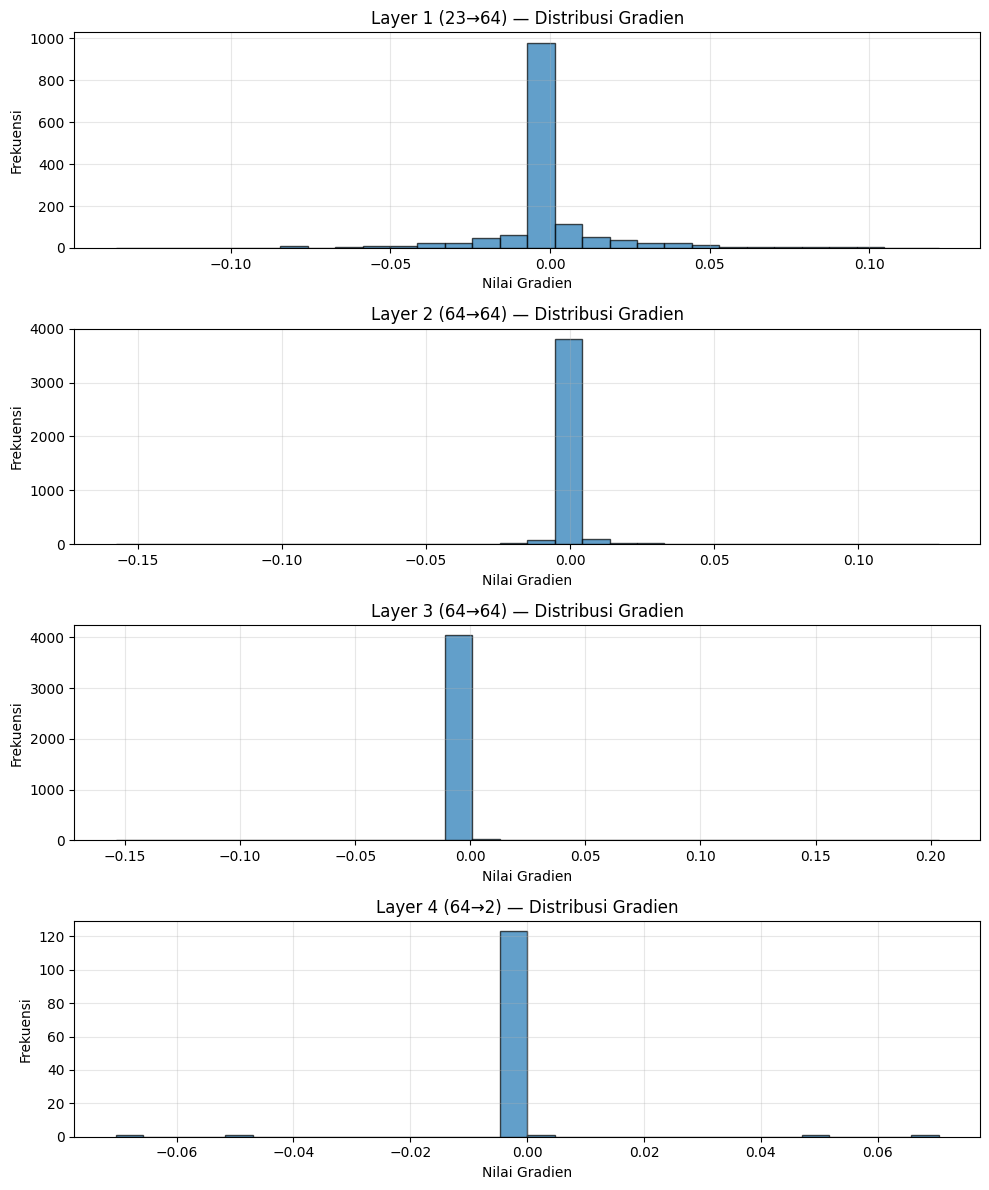


- Aktivasi: tanh


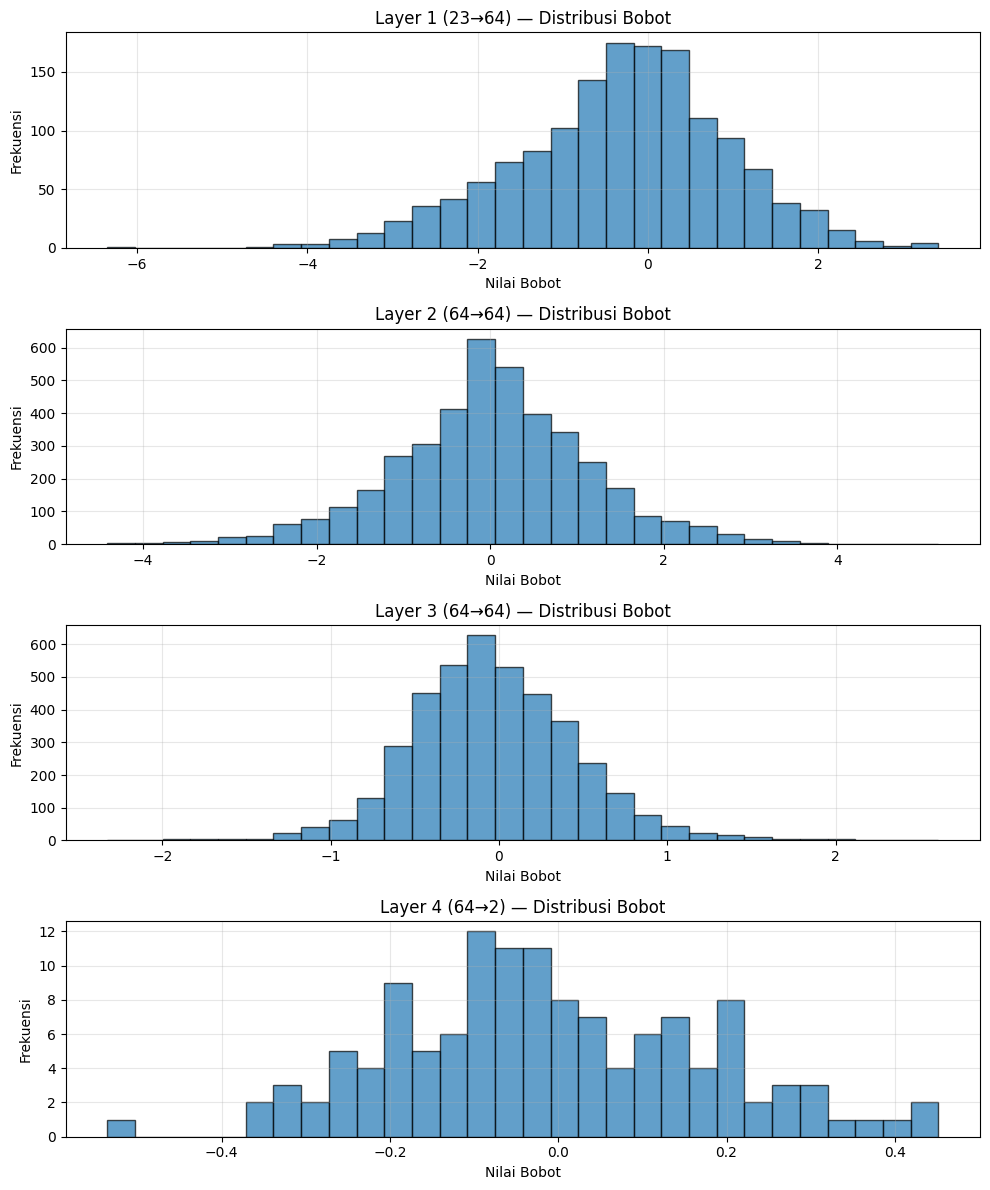

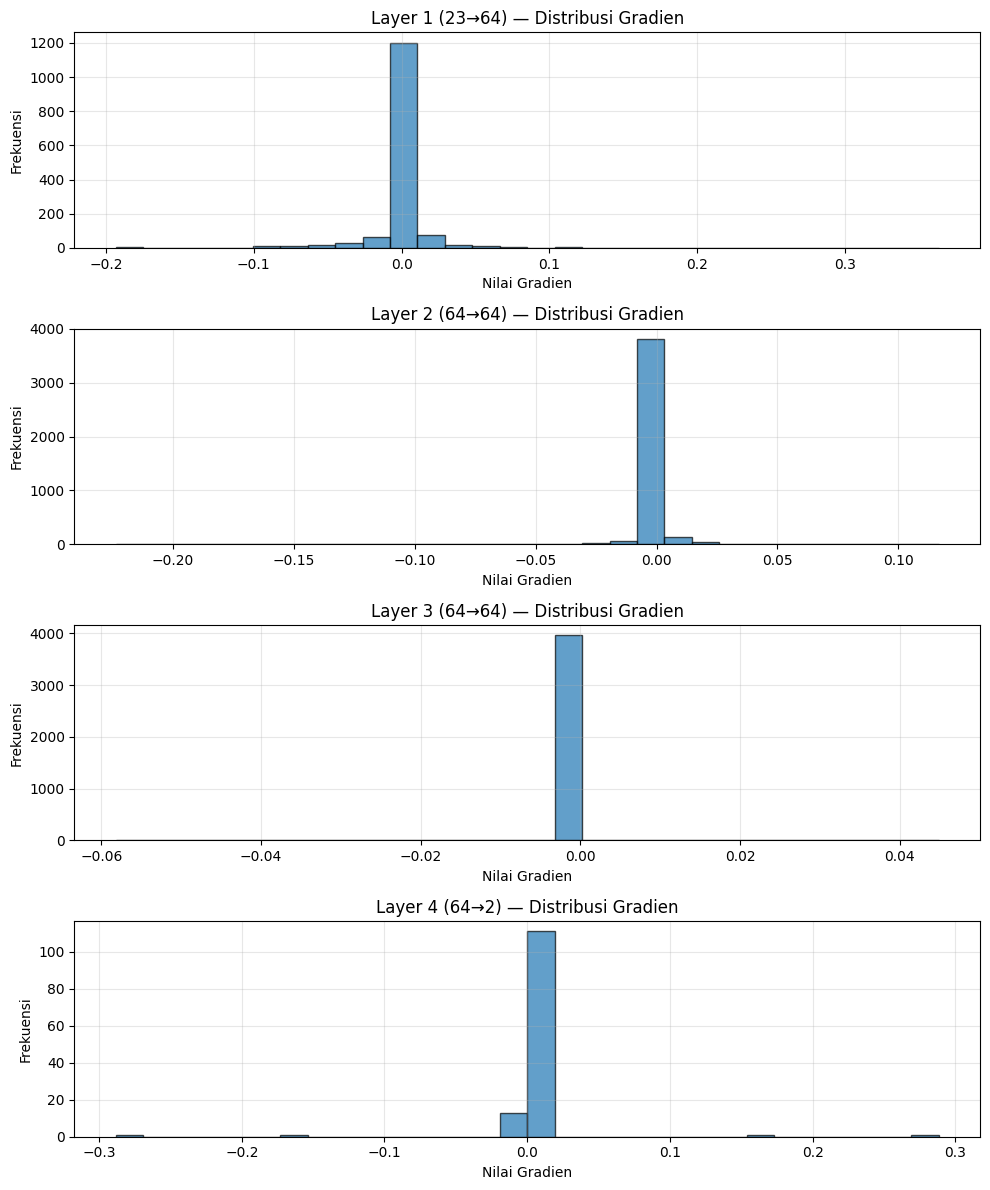

In [19]:
# Distribusi bobot dan gradien 
for act_name, model in act_models.items():
    print(f'\n- Aktivasi: {act_name}')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

---
## 3. Pengaruh Learning Rate

**3 variasi learning rate:** 0.001 (kecil), 0.01 (sedang), 0.1 (besar).

In [20]:
# load model
import os
SAVE_DIR_LR_MODELS = '../models/bab3_lr/'
lr_models = {}
lr_results = []
if os.path.exists(SAVE_DIR_LR_MODELS):
    for f in sorted(os.listdir(SAVE_DIR_LR_MODELS)):
        if f.endswith('.pkl'):
            name = f.replace('.pkl', '')
            lr_models[name] = FFNN.load(os.path.join(SAVE_DIR_LR_MODELS, f))
            print(f'  Loaded: {name}')
if lr_models:
    print(f'\nBerhasil load {len(lr_models)} model dari {SAVE_DIR_LR_MODELS}')
    for name, model in lr_models.items():
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        lr_results.append(res)
else:
    print('Tidak ada model tersimpan, akan training dari awal.')

  Loaded: LR=0.001
  Loaded: LR=0.01
  Loaded: LR=0.1

Berhasil load 3 model dari ../models/bab3_lr/
LR=0.001:
  Train Accuracy: 0.8957
  Val Accuracy:   0.7180
  Test Accuracy:  0.6793
LR=0.01:
  Train Accuracy: 0.8483
  Val Accuracy:   0.7227
  Test Accuracy:  0.7067
LR=0.1:
  Train Accuracy: 0.7643
  Val Accuracy:   0.7453
  Test Accuracy:  0.7347


In [21]:
base_arch = [n_features, 64, 64, 64, n_classes]
base_acts = ['relu', 'relu', 'relu', 'softmax']

if not lr_models:
    lr_values = [0.001, 0.01, 0.1]

    for lr in lr_values:
        name = f'LR={lr}'
        print(f'\n- {name}')

        model = FFNN(
            layer_sizes=base_arch,
            activations=base_acts,
            loss='categorical_cross_entropy',
            init_method='he',
            init_params={'distribution': 'normal', 'seed': 42}
        )
        model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=lr, epochs=EPOCHS, verbose=0, optimizer='adam')
        lr_models[name] = model
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        lr_results.append(res)
else:
    print('Model Bab 3 (Learning Rate) sudah di-load, skip training.')

Model Bab 3 (Learning Rate) sudah di-load, skip training.


In [22]:
# save model
import os
SAVE_DIR_LR_MODELS = '../models/bab3_lr/'
os.makedirs(SAVE_DIR_LR_MODELS, exist_ok=True)
for name, model in lr_models.items():
    model.save(os.path.join(SAVE_DIR_LR_MODELS, f'{name}.pkl'))
    print(f'  Saved: {name}')
print(f'Semua model Bab 3 (Learning Rate) disimpan di {SAVE_DIR_LR_MODELS}')

  Saved: LR=0.001
  Saved: LR=0.01
  Saved: LR=0.1
Semua model Bab 3 (Learning Rate) disimpan di ../models/bab3_lr/


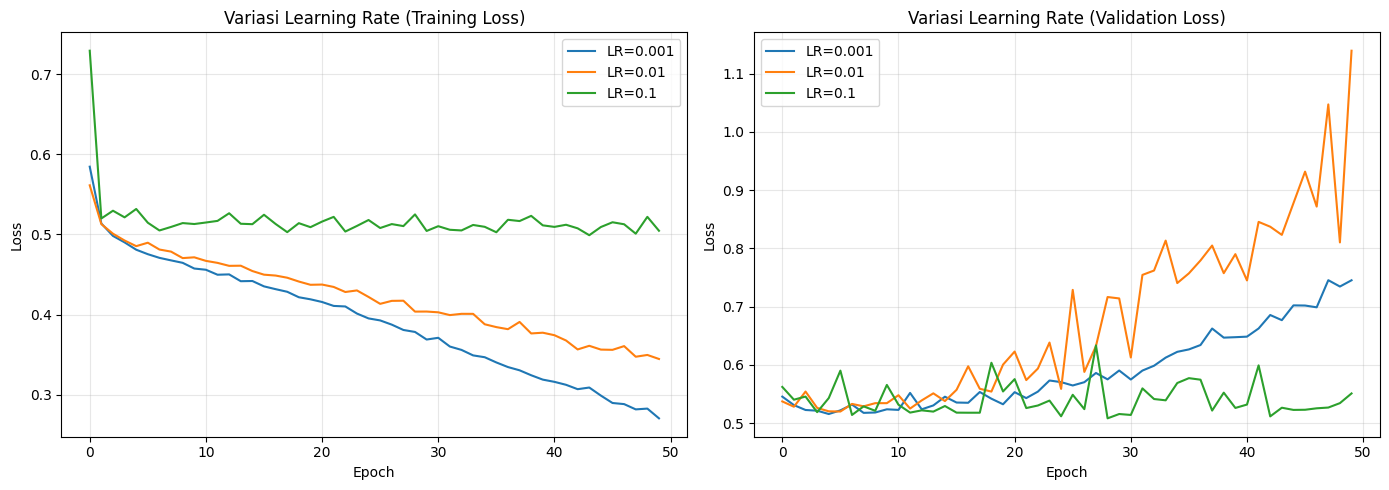

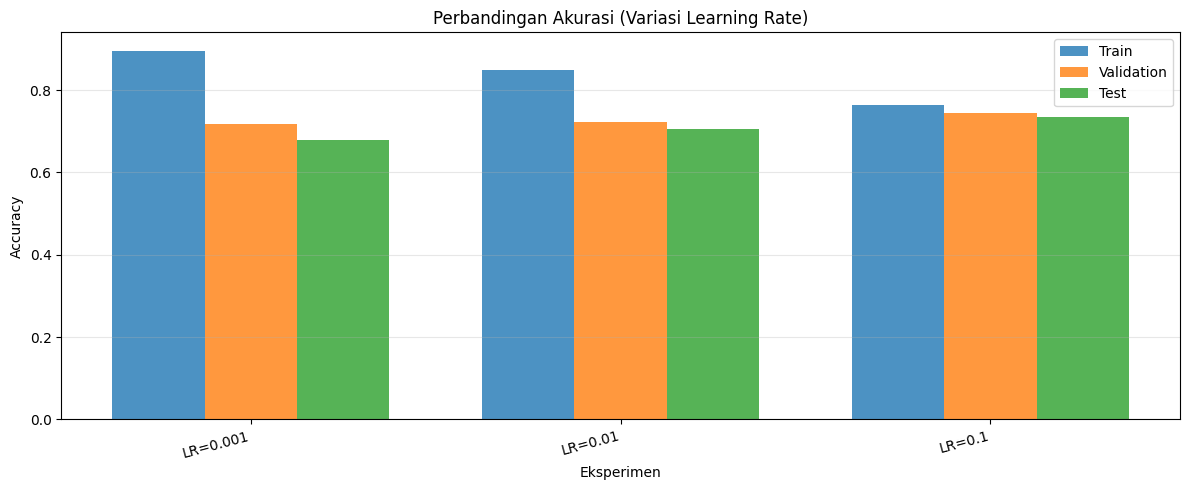

In [23]:
# Perbandingan loss dan akurasi
compare_loss(lr_models, 'Variasi Learning Rate')
compare_accuracy_bar(lr_results, 'Perbandingan Akurasi (Variasi Learning Rate)')


- LR=0.001


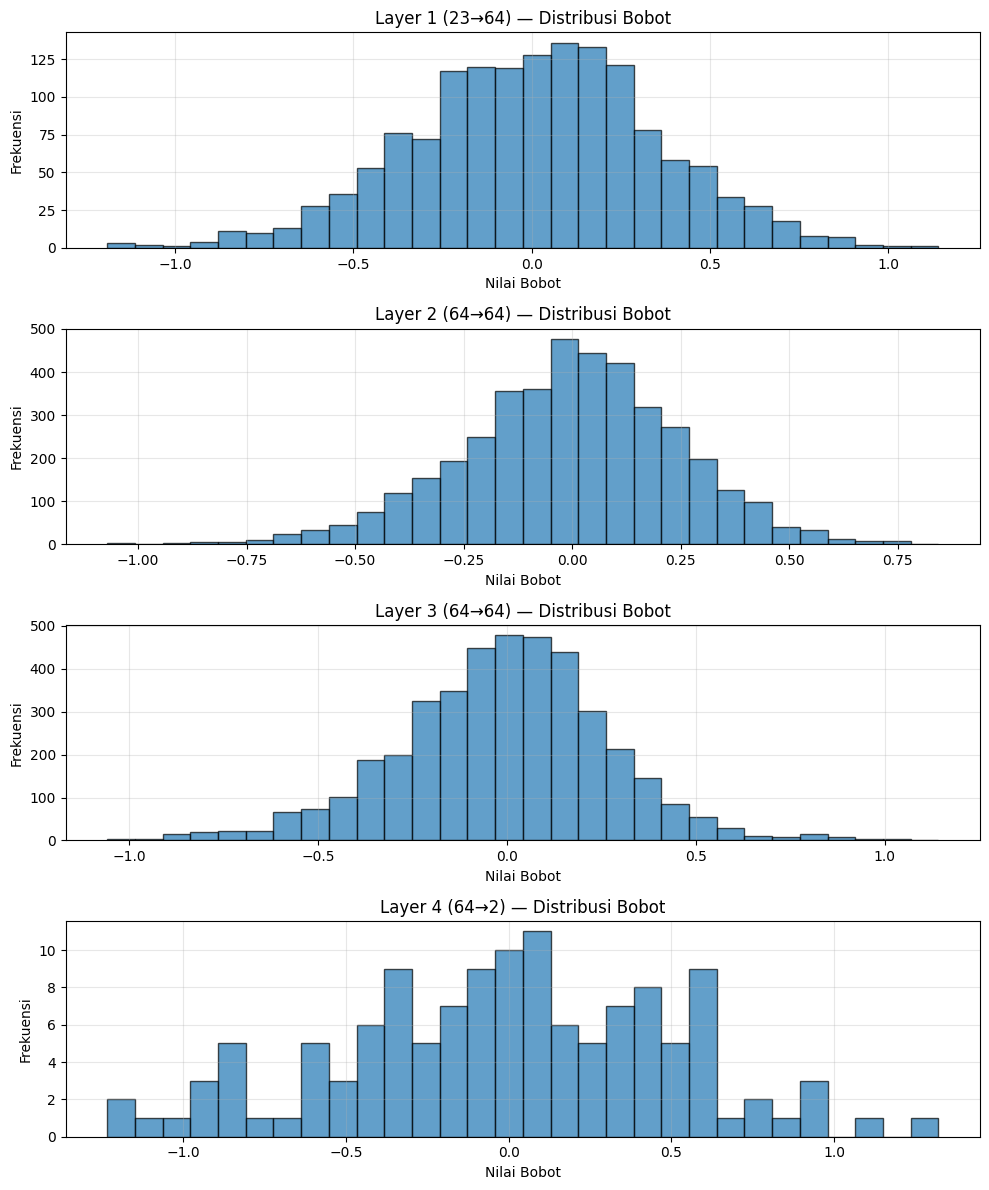

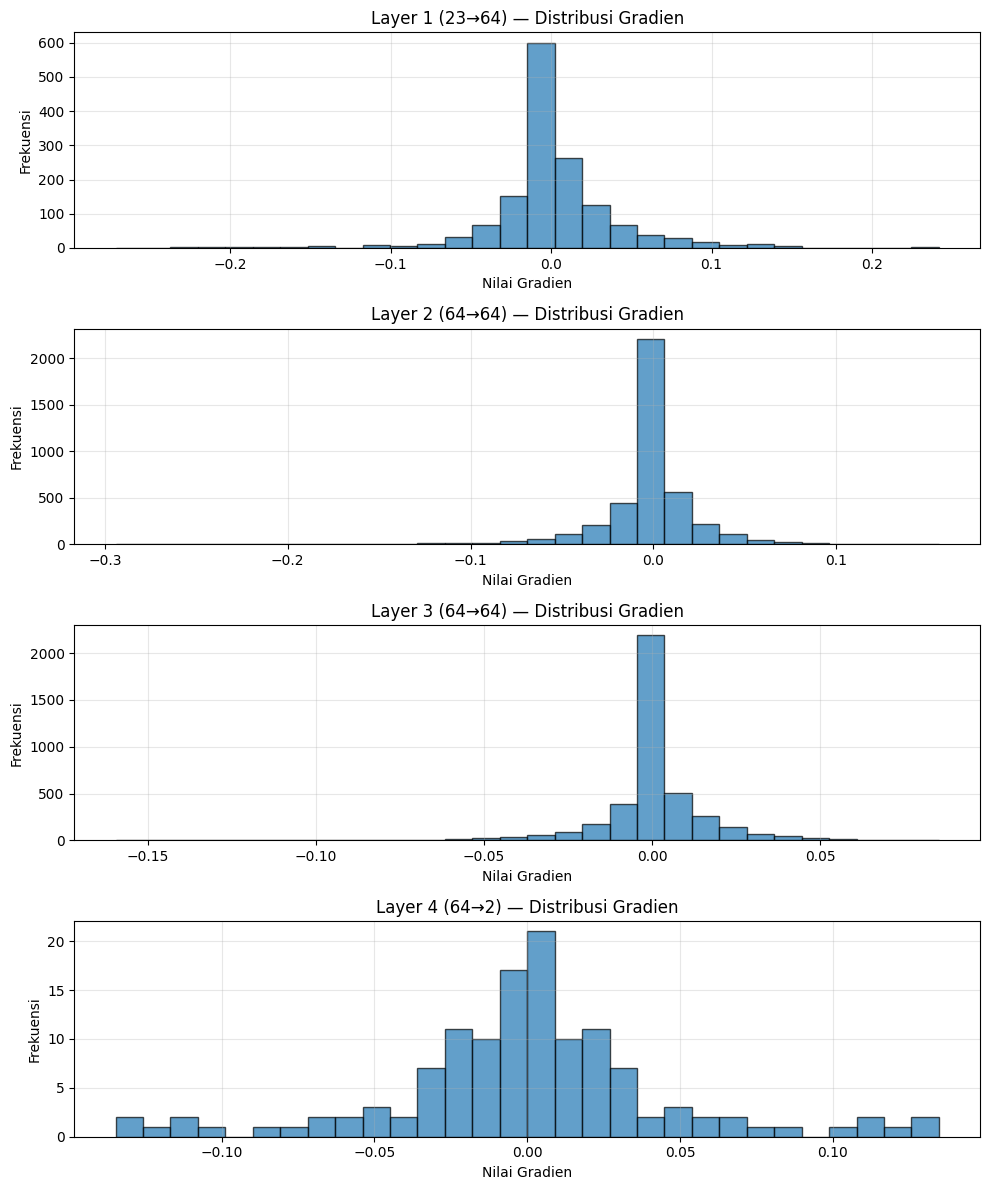


- LR=0.01


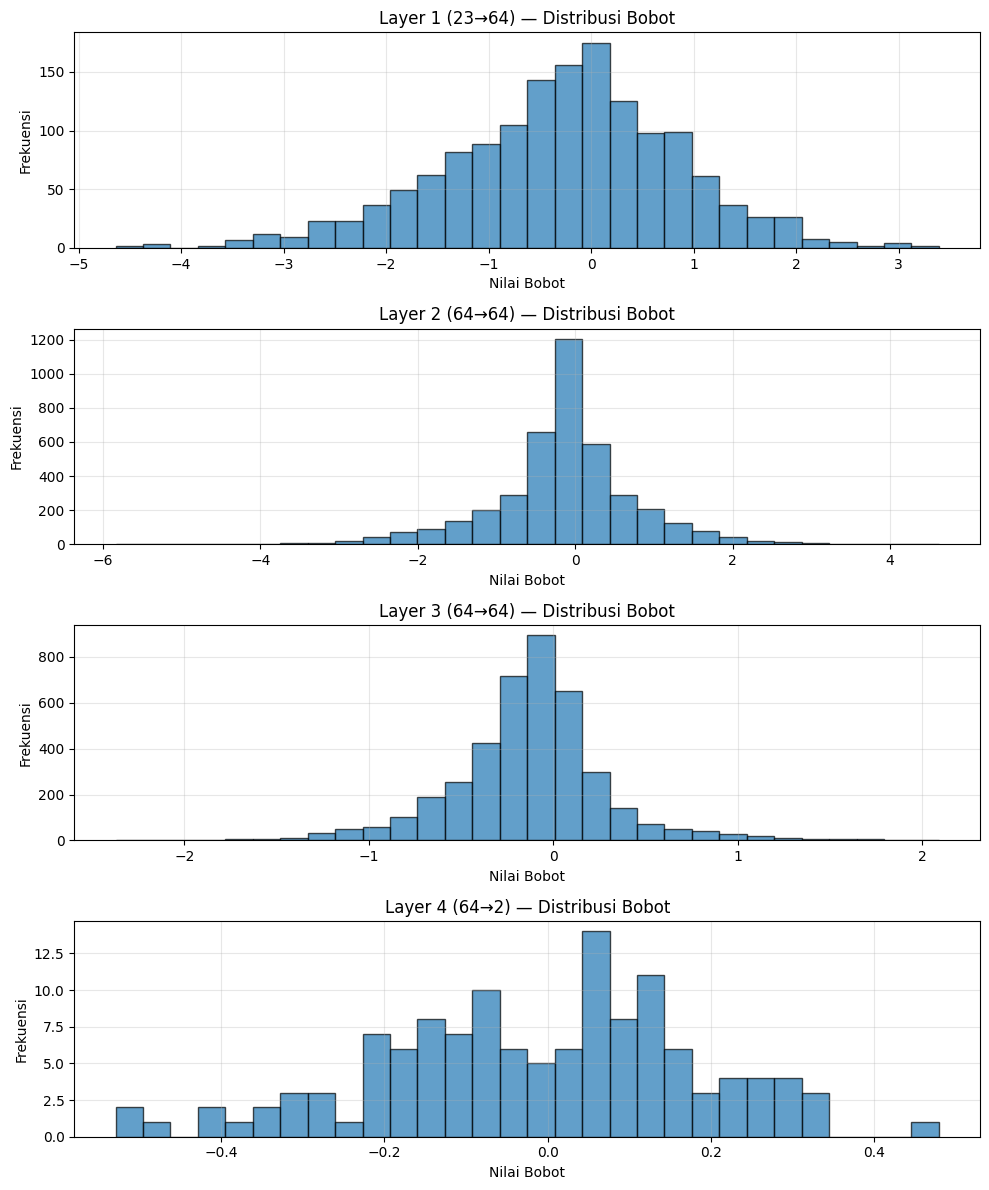

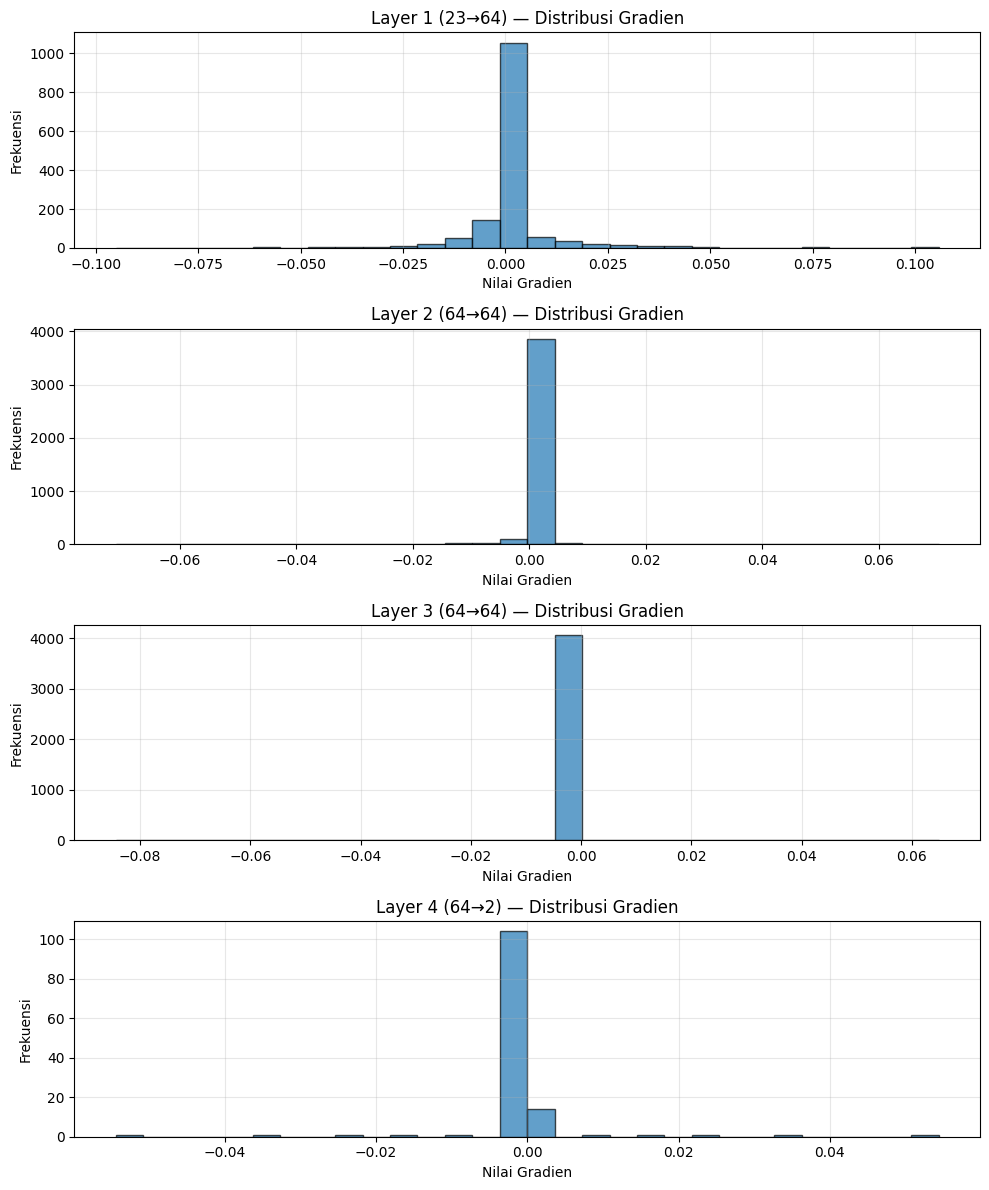


- LR=0.1


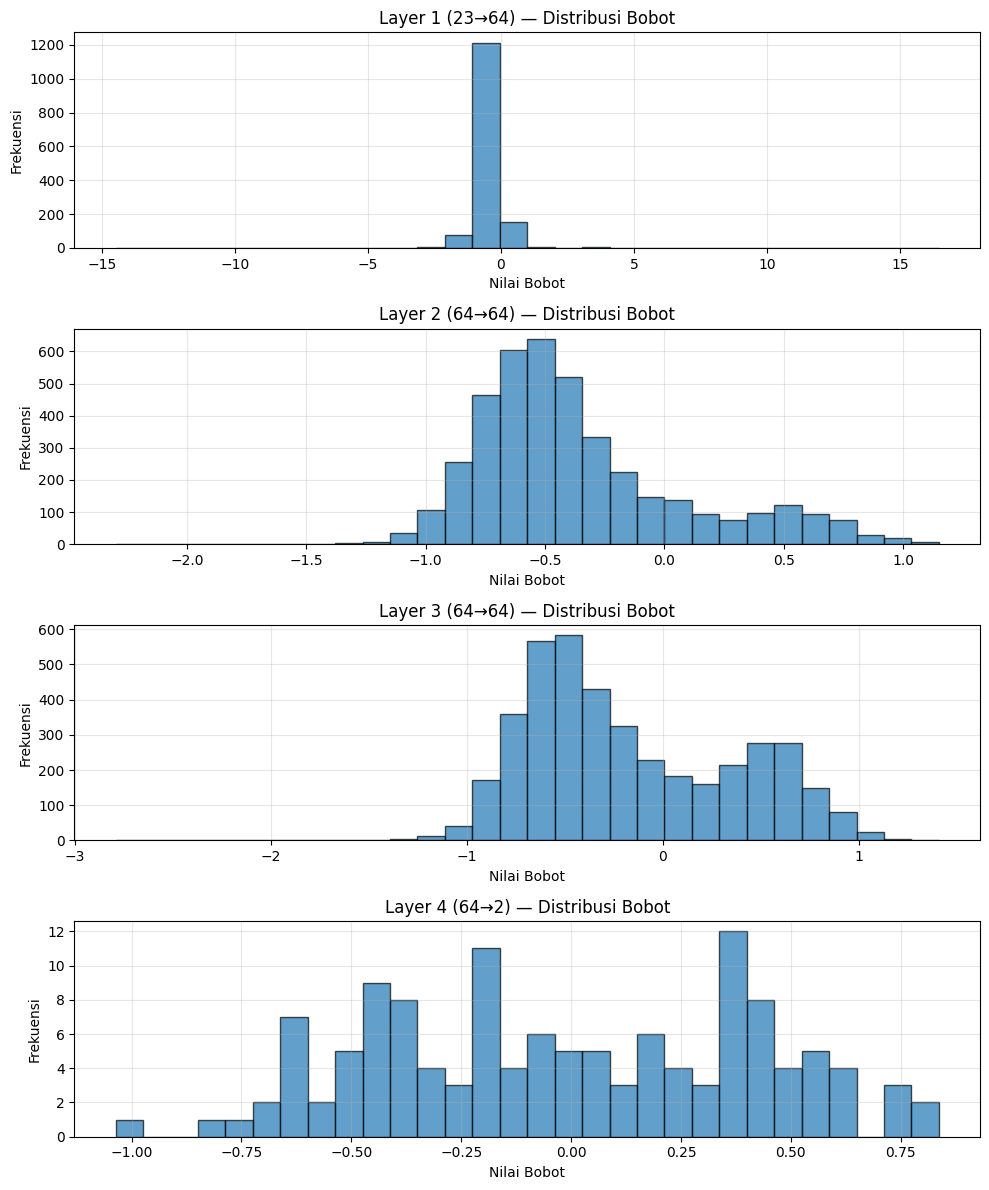

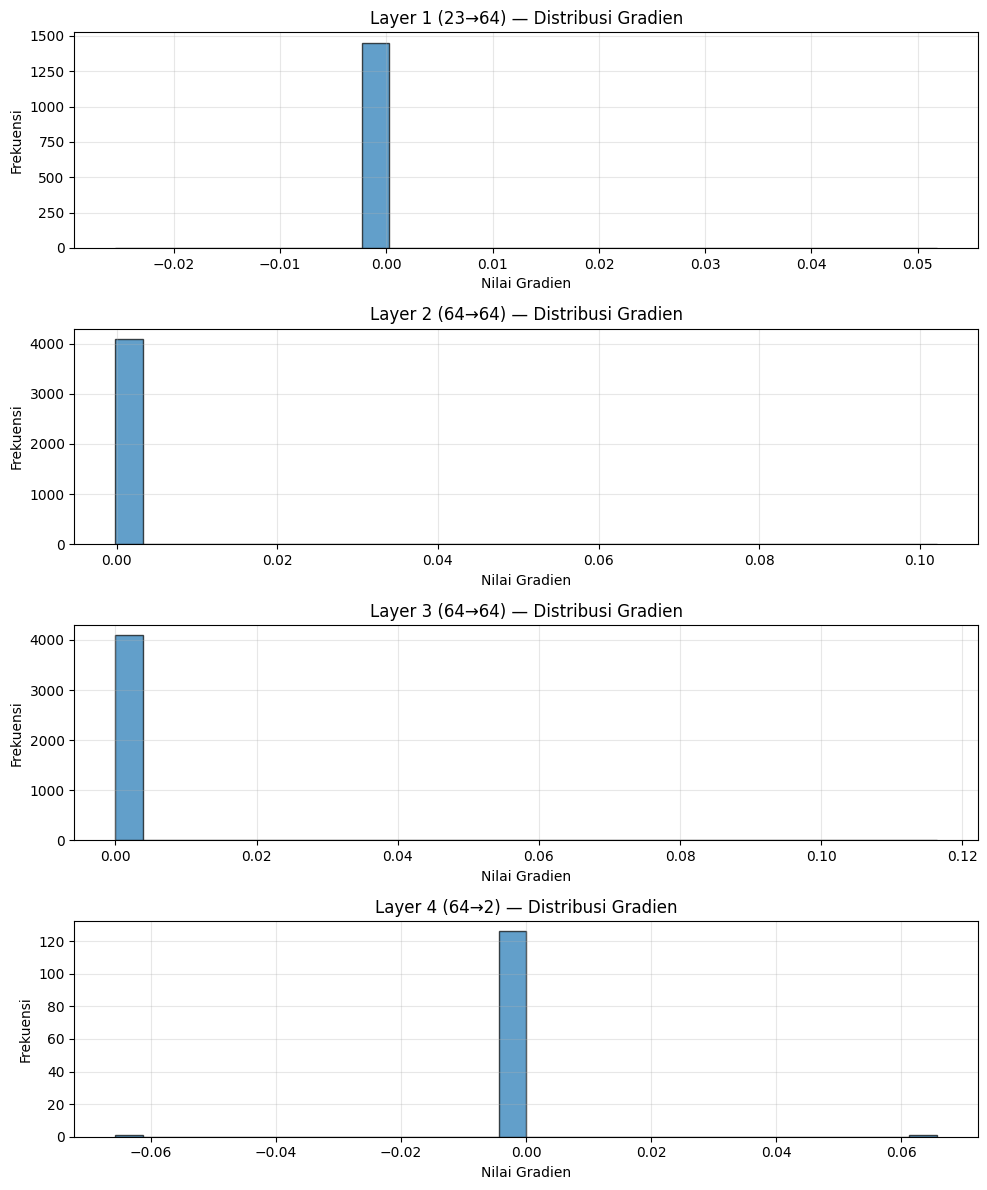

In [24]:
# Distribusi bobot dan gradien
for name, model in lr_models.items():
    print(f'\n- {name}')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

---
## 4. Pengaruh Regularisasi

**3 variasi:** tanpa regularisasi, L1 (λ=0.001), L2 (λ=0.001).

In [25]:
# load model
import os
SAVE_DIR_REG_MODELS = '../models/bab4_reg/'
reg_models = {}
reg_results = []
if os.path.exists(SAVE_DIR_REG_MODELS):
    for f in sorted(os.listdir(SAVE_DIR_REG_MODELS)):
        if f.endswith('.pkl'):
            name = f.replace('.pkl', '')
            reg_models[name] = FFNN.load(os.path.join(SAVE_DIR_REG_MODELS, f))
            print(f'  Loaded: {name}')
if reg_models:
    print(f'\nBerhasil load {len(reg_models)} model dari {SAVE_DIR_REG_MODELS}')
    for name, model in reg_models.items():
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        reg_results.append(res)
else:
    print('Tidak ada model tersimpan, akan training dari awal.')

  Loaded: L1 (λ=0.001)
  Loaded: L2 (λ=0.001)
  Loaded: Tanpa Regularisasi

Berhasil load 3 model dari ../models/bab4_reg/
L1 (λ=0.001):
  Train Accuracy: 0.7647
  Val Accuracy:   0.7433
  Test Accuracy:  0.7427
L2 (λ=0.001):
  Train Accuracy: 0.7656
  Val Accuracy:   0.7487
  Test Accuracy:  0.7373
Tanpa Regularisasi:
  Train Accuracy: 0.8390
  Val Accuracy:   0.7287
  Test Accuracy:  0.6947


In [26]:
if not reg_models:
    reg_configs = {
        'Tanpa Regularisasi': {'l1_lambda': 0.0, 'l2_lambda': 0.0},
        'L1 (λ=0.001)':      {'l1_lambda': 0.001, 'l2_lambda': 0.0},
        'L2 (λ=0.001)':      {'l1_lambda': 0.0, 'l2_lambda': 0.001},
    }

    for name, reg_params in reg_configs.items():
        print(f'\n- {name}')

        model = FFNN(
            layer_sizes=base_arch,
            activations=base_acts,
            loss='categorical_cross_entropy',
            init_method='he',
            init_params={'distribution': 'normal', 'seed': 42}
        )
        model.train(
            X_train, y_train, X_val, y_val,
            batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0, optimizer='adam',
            **reg_params
        )
        reg_models[name] = model
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        reg_results.append(res)
else:
    print('Model Bab 4 (Regularisasi) sudah di-load, skip training.')

Model Bab 4 (Regularisasi) sudah di-load, skip training.


In [27]:
# save model
import os
SAVE_DIR_REG_MODELS = '../models/bab4_reg/'
os.makedirs(SAVE_DIR_REG_MODELS, exist_ok=True)
for name, model in reg_models.items():
    model.save(os.path.join(SAVE_DIR_REG_MODELS, f'{name}.pkl'))
    print(f'  Saved: {name}')
print(f'Semua model Bab 4 (Regularisasi) disimpan di {SAVE_DIR_REG_MODELS}')

  Saved: L1 (λ=0.001)
  Saved: L2 (λ=0.001)
  Saved: Tanpa Regularisasi
Semua model Bab 4 (Regularisasi) disimpan di ../models/bab4_reg/


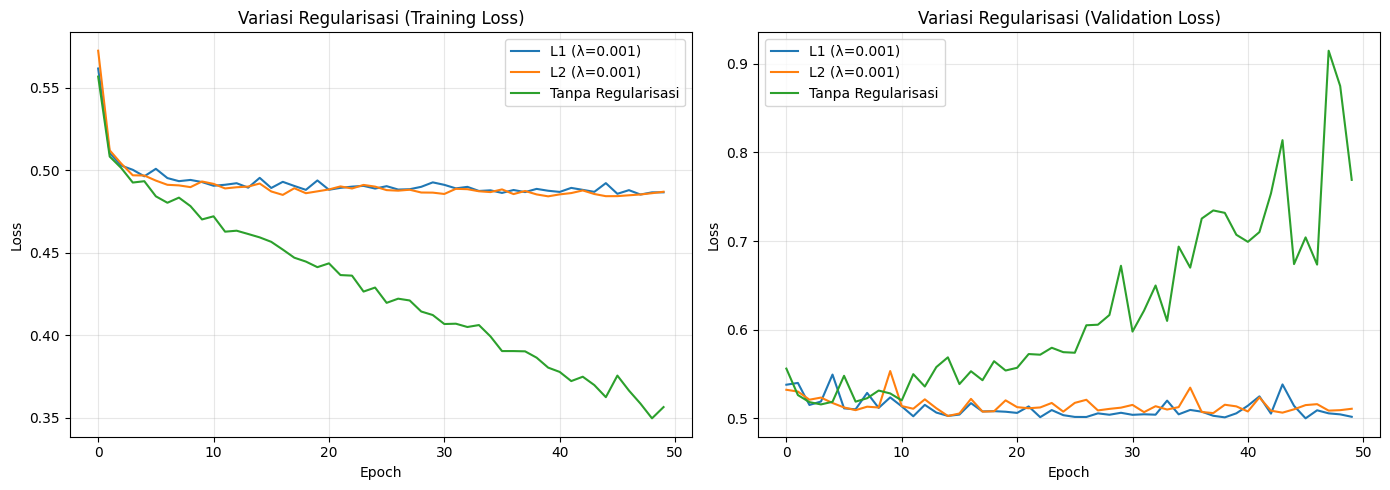

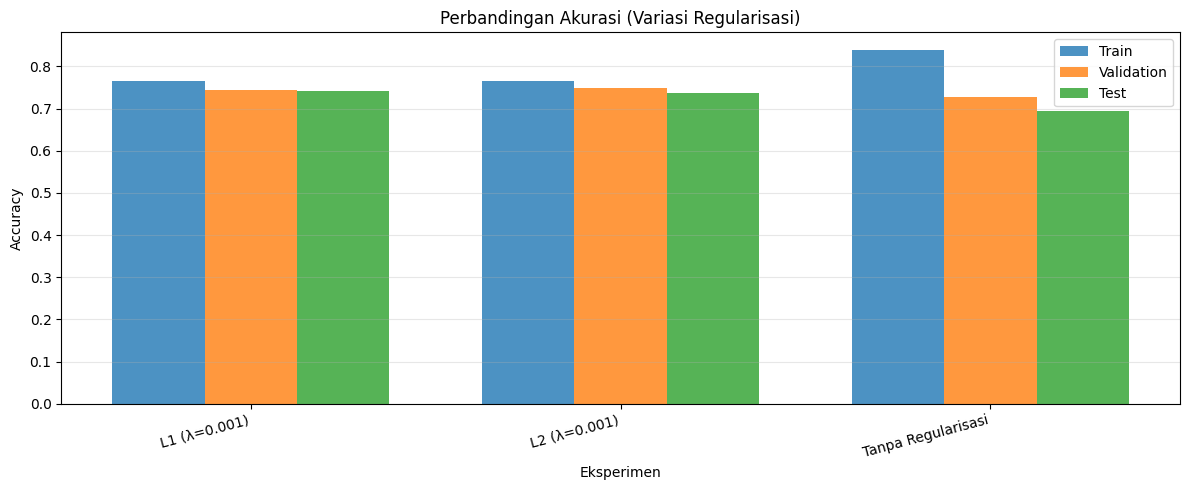

In [28]:
# Perbandingan loss dan akurasi
compare_loss(reg_models, 'Variasi Regularisasi')
compare_accuracy_bar(reg_results, 'Perbandingan Akurasi (Variasi Regularisasi)')


- L1 (λ=0.001)


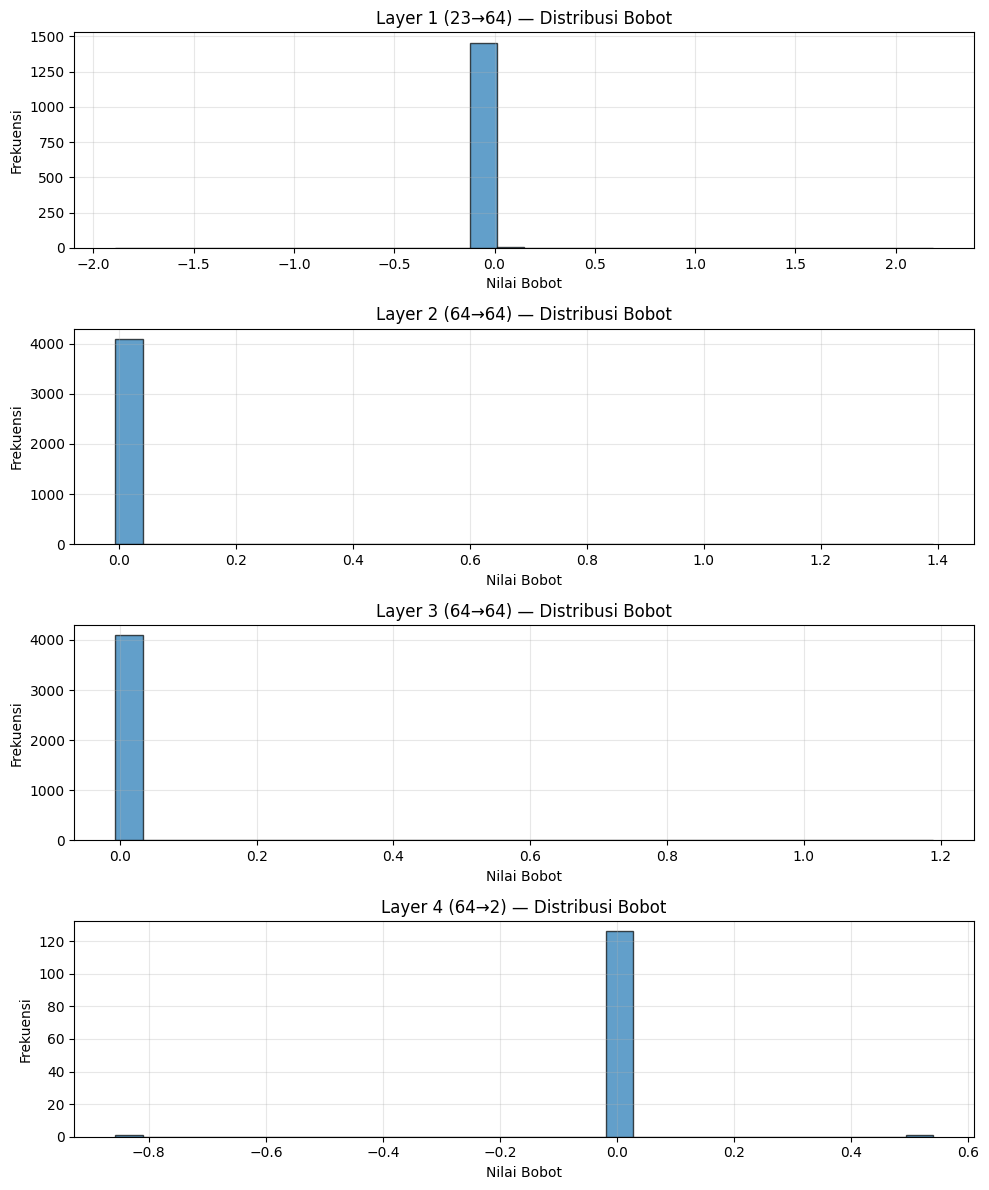

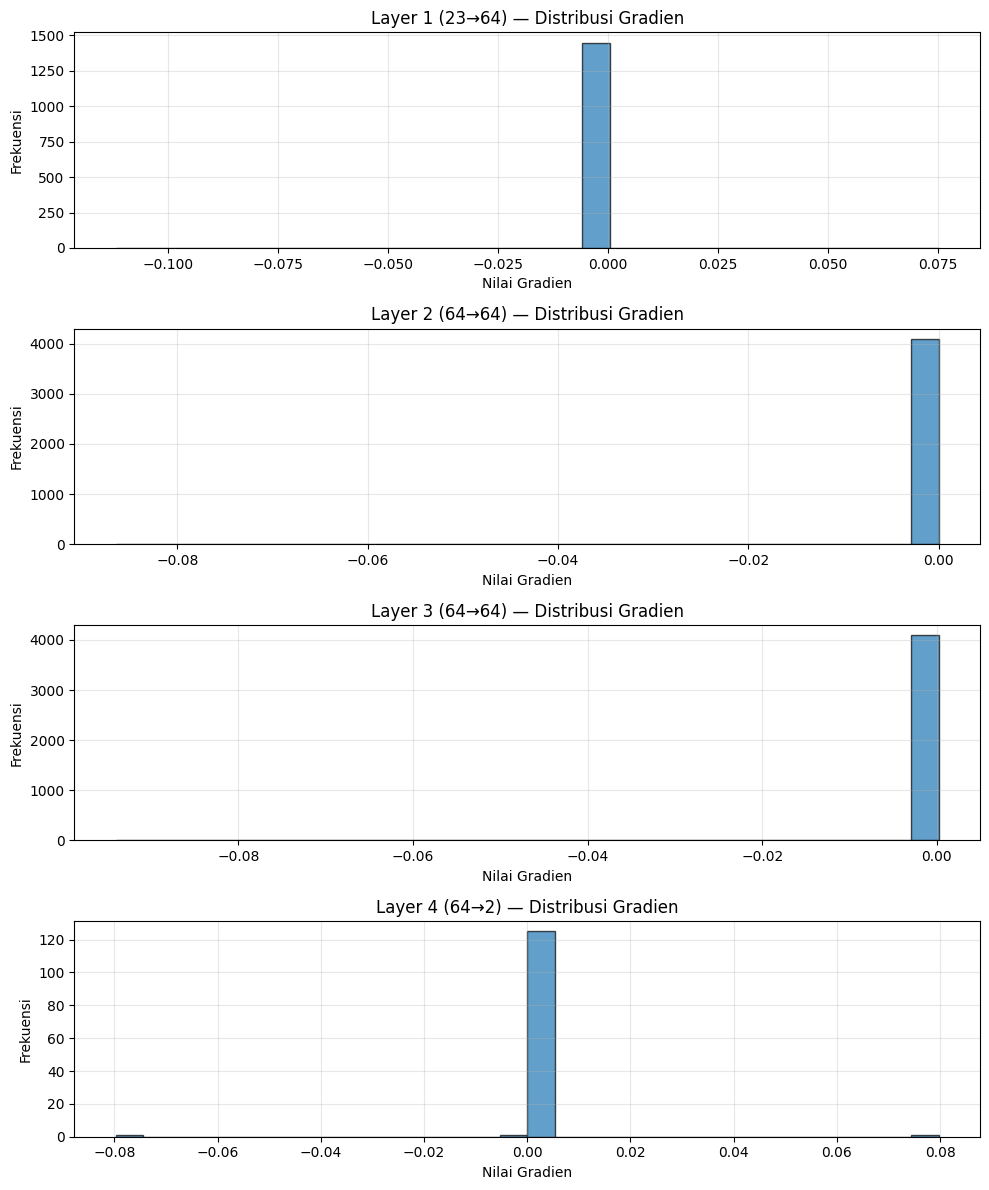


- L2 (λ=0.001)


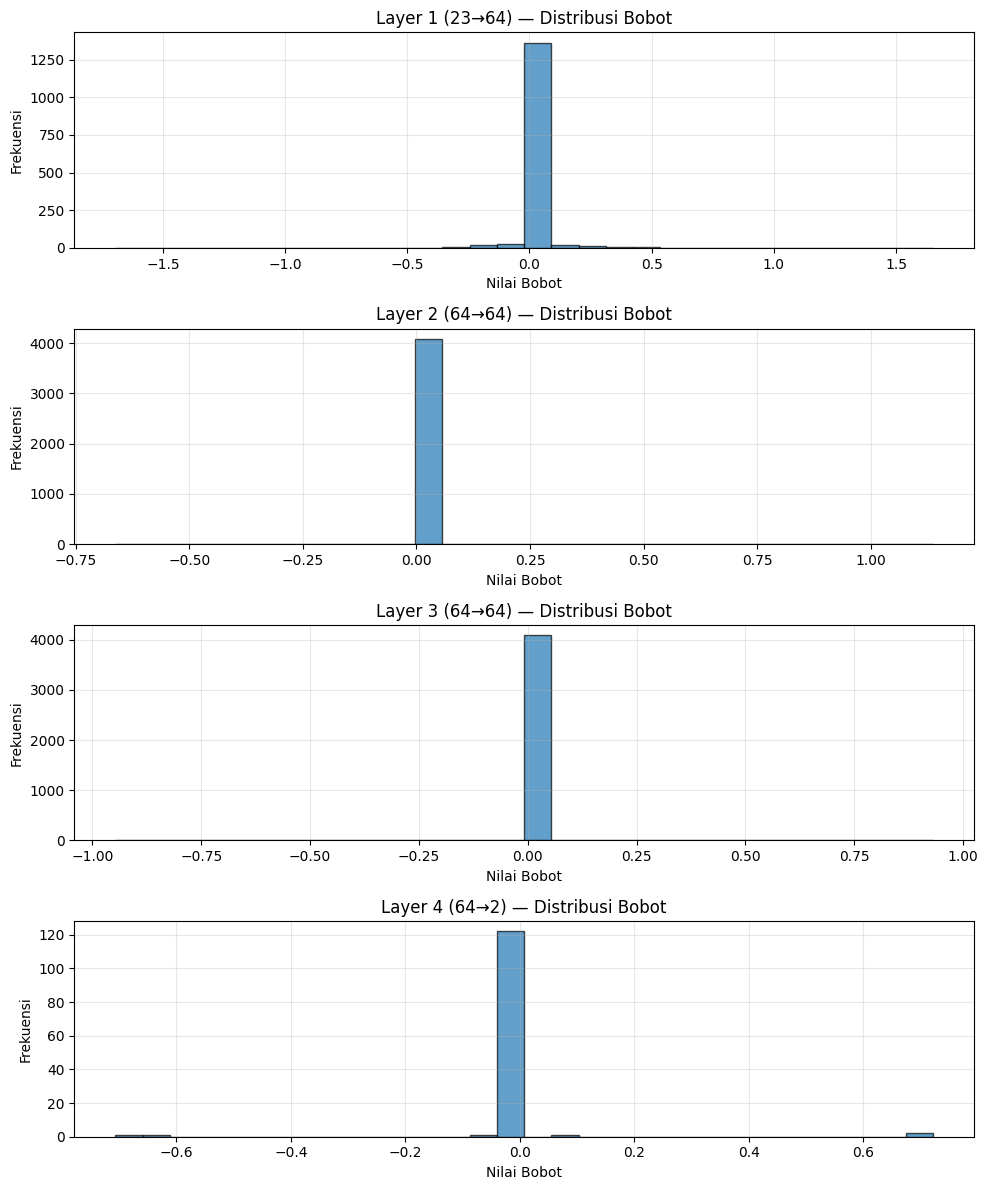

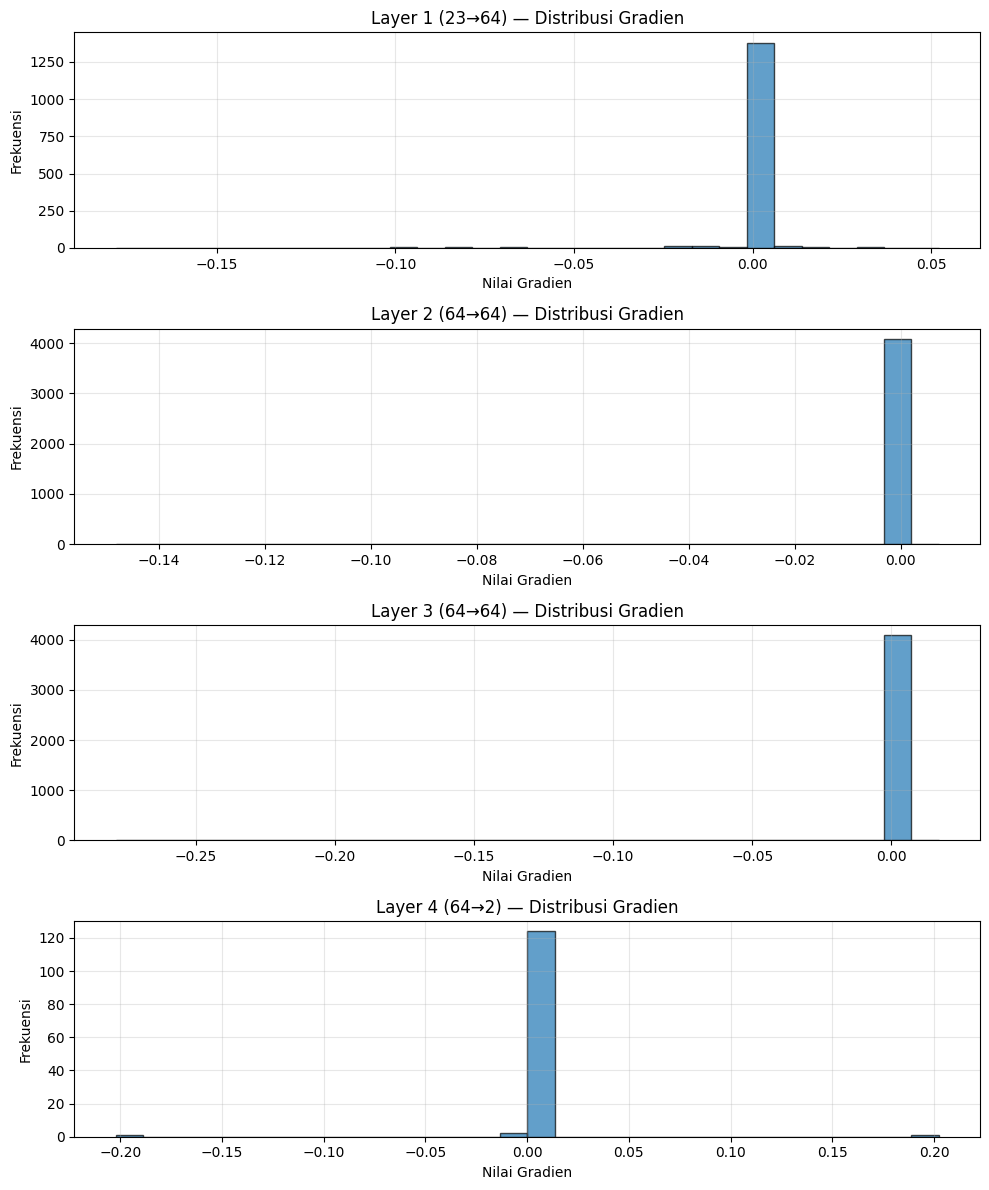


- Tanpa Regularisasi


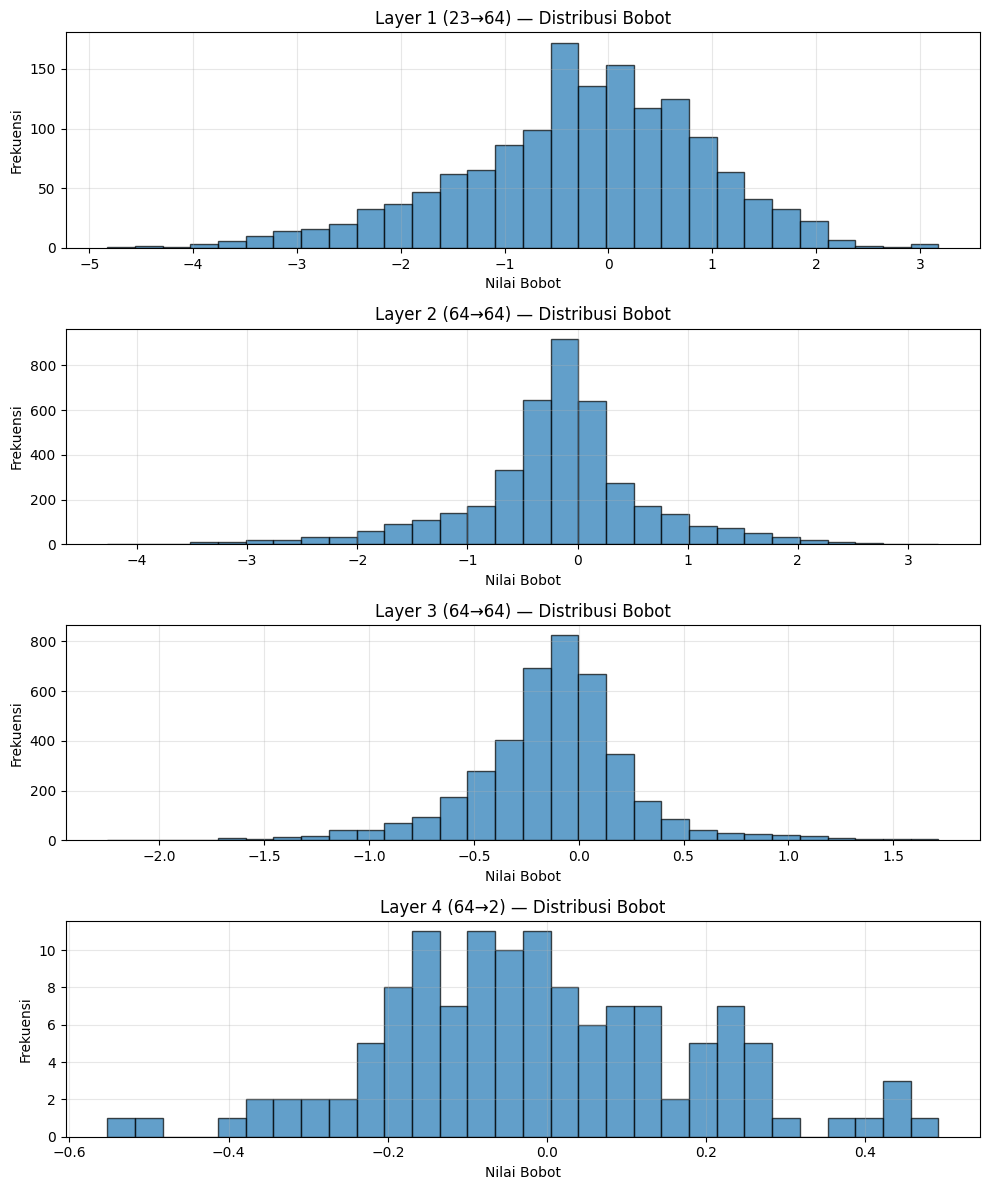

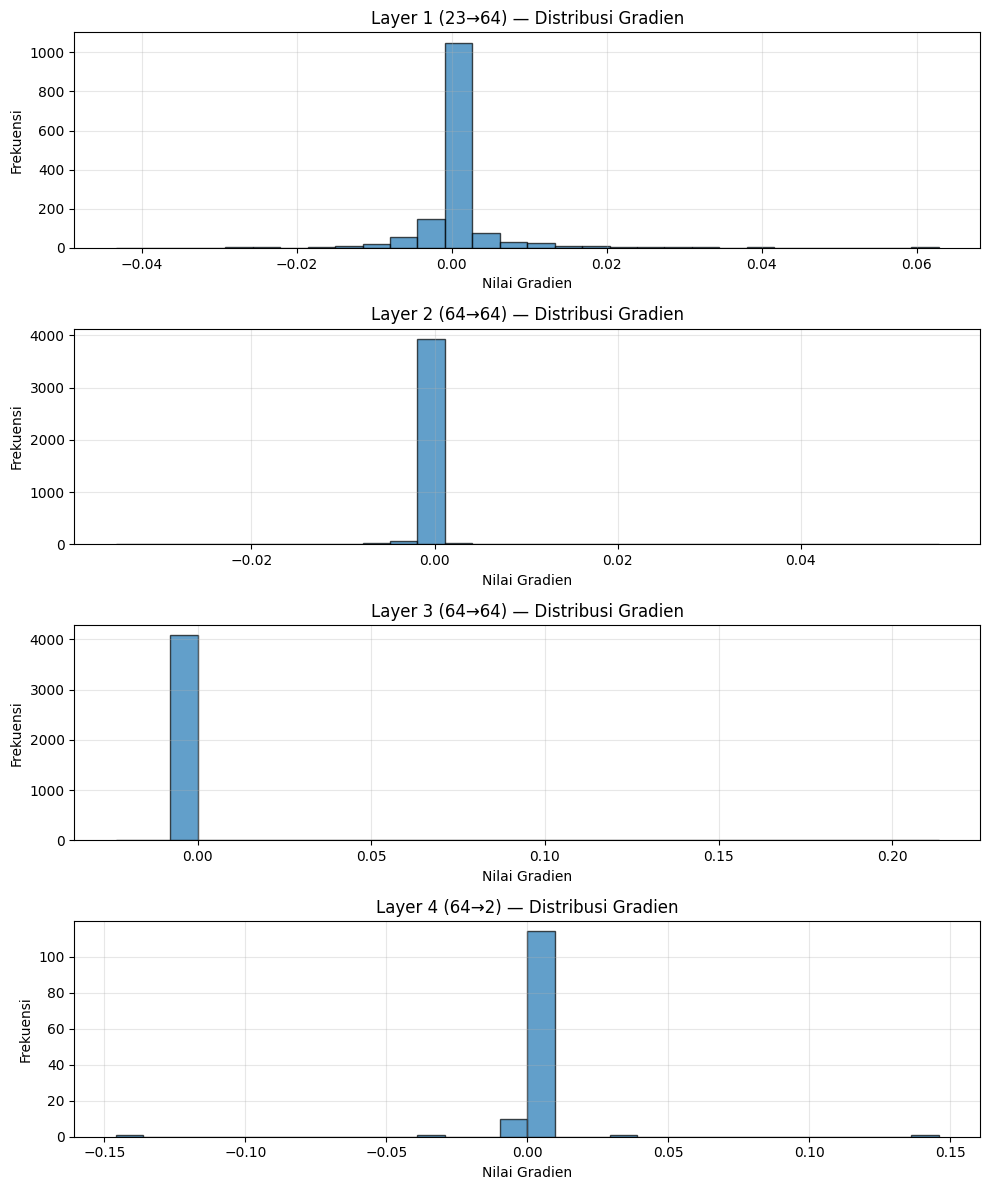

In [29]:
# Distribusi bobot dan gradien
for name, model in reg_models.items():
    print(f'\n- {name}')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

---
## 5. Uji Perbandingan: FFNN vs sklearn MLPClassifier

Hyperparameter:
- Arsitektur: (64, 64, 64) hidden layers
- Fungsi aktivasi: ReLU
- Learning rate: 0.01
- Epochs: 50
- Batch size: 32

In [30]:
# load model
import os
SAVE_PATH_BAB5 = '../models/bab5_sklearn/ffnn_model.pkl'
ffnn_model = None
if os.path.exists(SAVE_PATH_BAB5):
    ffnn_model = FFNN.load(SAVE_PATH_BAB5)
    print(f'Loaded ffnn_model dari {SAVE_PATH_BAB5}')
    ffnn_train_acc = accuracy(ffnn_model, X_train, y_train)
    ffnn_val_acc = accuracy(ffnn_model, X_val, y_val)
    ffnn_test_acc = accuracy(ffnn_model, X_test, y_test)
    print(f'  Train Accuracy: {ffnn_train_acc:.4f}')
    print(f'  Val Accuracy:   {ffnn_val_acc:.4f}')
    print(f'  Test Accuracy:  {ffnn_test_acc:.4f}')
else:
    print('Tidak ada model tersimpan, akan training dari awal.')

Loaded ffnn_model dari ../models/bab5_sklearn/ffnn_model.pkl
  Train Accuracy: 0.8466
  Val Accuracy:   0.7307
  Test Accuracy:  0.7120


In [31]:
if ffnn_model is None:
    print('- FFNN (From Scratch)')
    ffnn_model = FFNN(
        layer_sizes=[n_features, 64, 64, 64, n_classes],
        activations=['relu', 'relu', 'relu', 'softmax'],
        loss='categorical_cross_entropy',
        init_method='he',
        init_params={'distribution': 'normal', 'seed': 42}
    )
    ffnn_model.train(X_train, y_train, X_val, y_val, batch_size=32, learning_rate=0.01, epochs=50, verbose=0, optimizer='adam')

    ffnn_train_acc = accuracy(ffnn_model, X_train, y_train)
    ffnn_val_acc = accuracy(ffnn_model, X_val, y_val)
    ffnn_test_acc = accuracy(ffnn_model, X_test, y_test)
    print(f'  Train Accuracy: {ffnn_train_acc:.4f}')
    print(f'  Val Accuracy:   {ffnn_val_acc:.4f}')
    print(f'  Test Accuracy:  {ffnn_test_acc:.4f}')
else:
    print('Model Bab 5 sudah di-load, skip training.')

Model Bab 5 sudah di-load, skip training.


In [32]:
# save model
import os
SAVE_DIR_BAB5 = '../models/bab5_sklearn/'
os.makedirs(SAVE_DIR_BAB5, exist_ok=True)
ffnn_model.save(os.path.join(SAVE_DIR_BAB5, 'ffnn_model.pkl'))
print(f'Model FFNN disimpan di {SAVE_DIR_BAB5}ffnn_model.pkl')

Model FFNN disimpan di ../models/bab5_sklearn/ffnn_model.pkl


In [33]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print('\n- Sklearn MLPClassifier')

# Konversi target dari one-hot ke label integer
y_train_labels = np.argmax(y_train, axis=1)
y_val_labels = np.argmax(y_val, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

sklearn_model = MLPClassifier(
    hidden_layer_sizes=(64, 64, 64),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    batch_size=32,
    max_iter=50,
    random_state=42,
    verbose=False
)
sklearn_model.fit(X_train, y_train_labels)

sk_train_acc = accuracy_score(y_train_labels, sklearn_model.predict(X_train))
sk_val_acc = accuracy_score(y_val_labels, sklearn_model.predict(X_val))
sk_test_acc = accuracy_score(y_test_labels, sklearn_model.predict(X_test))
print(f'  Train Accuracy: {sk_train_acc:.4f}')
print(f'  Val Accuracy:   {sk_val_acc:.4f}')
print(f'  Test Accuracy:  {sk_test_acc:.4f}')


- Sklearn MLPClassifier
  Train Accuracy: 0.8074
  Val Accuracy:   0.7413
  Test Accuracy:  0.7153


C:\Users\Matthew\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


              Model  Train Accuracy  Validation Accuracy  Test Accuracy
FFNN (From Scratch)        0.846571             0.730667       0.712000
        sklearn MLP        0.807429             0.741333       0.715333


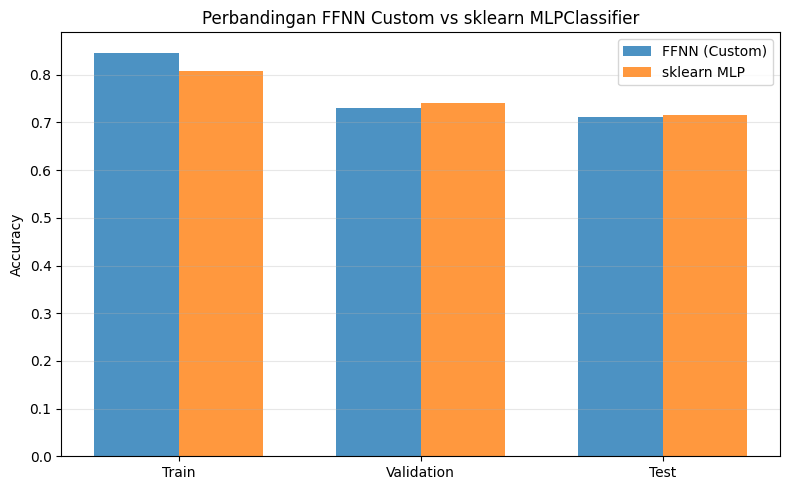

In [34]:
comparison = pd.DataFrame({
    'Model': ['FFNN (From Scratch)', 'sklearn MLP'],
    'Train Accuracy': [ffnn_train_acc, sk_train_acc],
    'Validation Accuracy': [ffnn_val_acc, sk_val_acc],
    'Test Accuracy': [ffnn_test_acc, sk_test_acc]
})
print(comparison.to_string(index=False))

# Bar chart perbandingan
x = np.arange(3)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, [ffnn_train_acc, ffnn_val_acc, ffnn_test_acc], width, label='FFNN (Custom)', alpha=0.8)
ax.bar(x + width/2, [sk_train_acc, sk_val_acc, sk_test_acc], width, label='sklearn MLP', alpha=0.8)
ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan FFNN Custom vs sklearn MLPClassifier')
ax.set_xticks(x)
ax.set_xticklabels(['Train', 'Validation', 'Test'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 6. Pengaruh Inisialisasi Bobot

Eksperimen membandingkan 5 metode inisialisasi bobot:
- **Zero** 
- **Random Uniform** 
- **Random Normal** 
- **Xavier/Glorot** 
- **He/Kaiming** 

Arsitektur tetap: [n_features, 64, 64, 64, n_classes], ReLU + Softmax, CCE loss.

In [35]:
# load model
import os
SAVE_DIR_INIT_MODELS = '../models/bab6_init/'
init_models = {}
init_results = []
if os.path.exists(SAVE_DIR_INIT_MODELS):
    for f in sorted(os.listdir(SAVE_DIR_INIT_MODELS)):
        if f.endswith('.pkl'):
            name = f.replace('.pkl', '')
            init_models[name] = FFNN.load(os.path.join(SAVE_DIR_INIT_MODELS, f))
            print(f'  Loaded: {name}')
if init_models:
    print(f'\nBerhasil load {len(init_models)} model dari {SAVE_DIR_INIT_MODELS}')
    for name, model in init_models.items():
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        init_results.append(res)
else:
    print('Tidak ada model tersimpan, akan training dari awal.')

  Loaded: He
  Loaded: Normal
  Loaded: Uniform
  Loaded: Xavier
  Loaded: Zero

Berhasil load 5 model dari ../models/bab6_init/
He:
  Train Accuracy: 0.8399
  Val Accuracy:   0.7107
  Test Accuracy:  0.7000
Normal:
  Train Accuracy: 0.8186
  Val Accuracy:   0.7127
  Test Accuracy:  0.7007
Uniform:
  Train Accuracy: 0.8841
  Val Accuracy:   0.6853
  Test Accuracy:  0.6687
Xavier:
  Train Accuracy: 0.8149
  Val Accuracy:   0.7373
  Test Accuracy:  0.7173
Zero:
  Train Accuracy: 0.6167
  Val Accuracy:   0.6133
  Test Accuracy:  0.6107


In [36]:
if not init_models:
    init_configs = {
        'Zero':    {'init_method': 'zero',    'init_params': {}},
        'Uniform': {'init_method': 'uniform', 'init_params': {'lower_bound': -1.0, 'upper_bound': 1.0, 'seed': 42}},
        'Normal':  {'init_method': 'normal',  'init_params': {'mean': 0.0, 'variance': 1.0, 'seed': 42}},
        'Xavier':  {'init_method': 'xavier',  'init_params': {'distribution': 'uniform', 'seed': 42}},
        'He':      {'init_method': 'he',      'init_params': {'distribution': 'normal', 'seed': 42}},
    }


    for name, cfg in init_configs.items():
        print(f'\n- Inisialisasi: {name}')

        model = FFNN(
            layer_sizes=base_arch,
            activations=base_acts,
            loss='categorical_cross_entropy',
            init_method=cfg['init_method'],
            init_params=cfg['init_params']
        )
        model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0, optimizer='adam')
        init_models[name] = model
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        init_results.append(res)
else:
    print('Model Bab 6 (Inisialisasi) sudah di-load, skip training.')

Model Bab 6 (Inisialisasi) sudah di-load, skip training.


In [37]:
# Save model
import os
SAVE_DIR_INIT_MODELS = '../models/bab6_init/'
os.makedirs(SAVE_DIR_INIT_MODELS, exist_ok=True)
for name, model in init_models.items():
    model.save(os.path.join(SAVE_DIR_INIT_MODELS, f'{name}.pkl'))
    print(f'  Saved: {name}')
print(f'Semua model Bab 6 (Inisialisasi) disimpan di {SAVE_DIR_INIT_MODELS}')

  Saved: He
  Saved: Normal
  Saved: Uniform
  Saved: Xavier
  Saved: Zero
Semua model Bab 6 (Inisialisasi) disimpan di ../models/bab6_init/


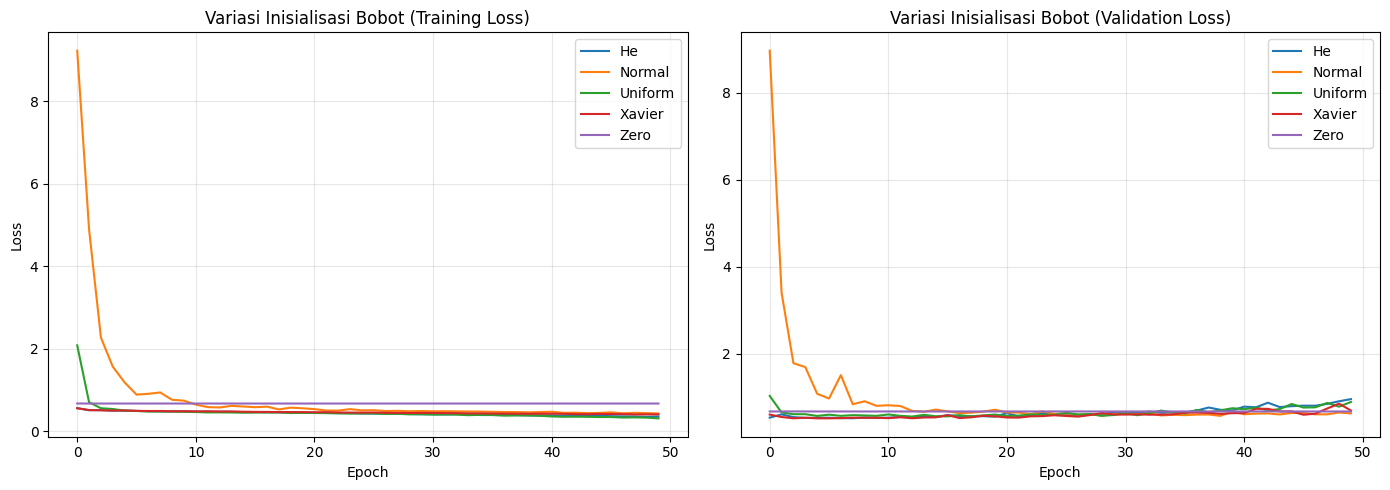

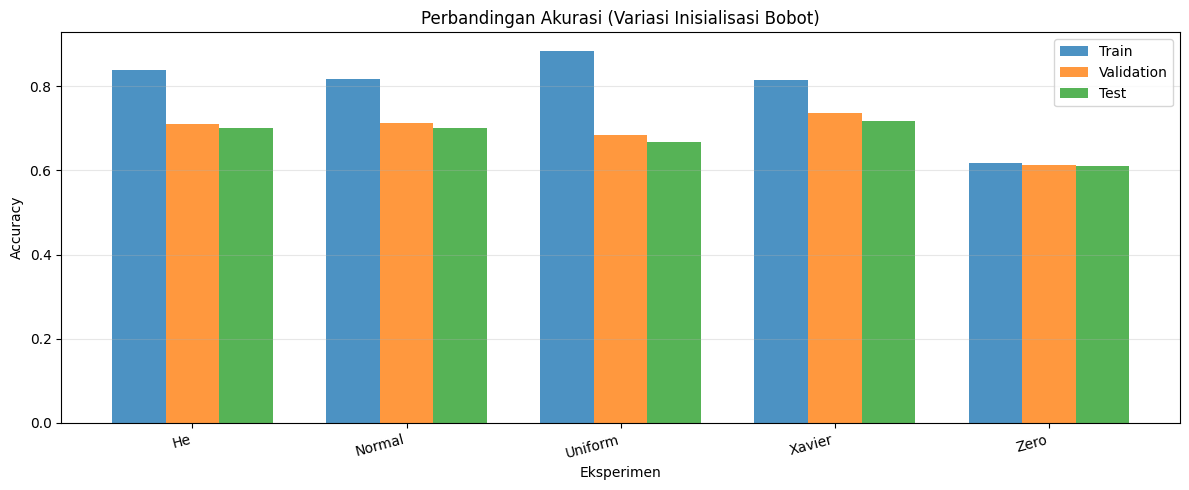

In [38]:
# Perbandingan loss dan akurasi
compare_loss(init_models, 'Variasi Inisialisasi Bobot')
compare_accuracy_bar(init_results, 'Perbandingan Akurasi (Variasi Inisialisasi Bobot)')


- Inisialisasi: He


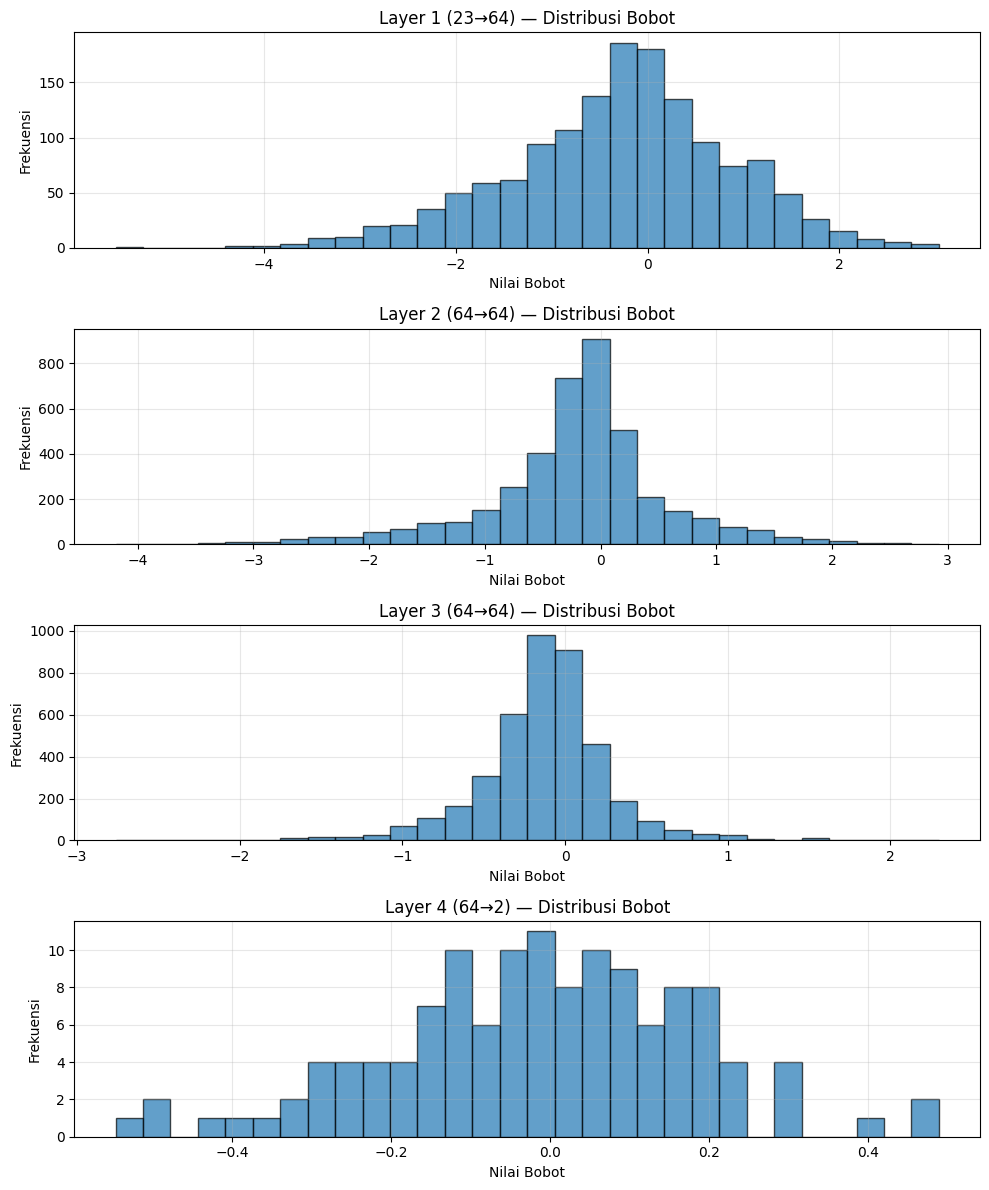

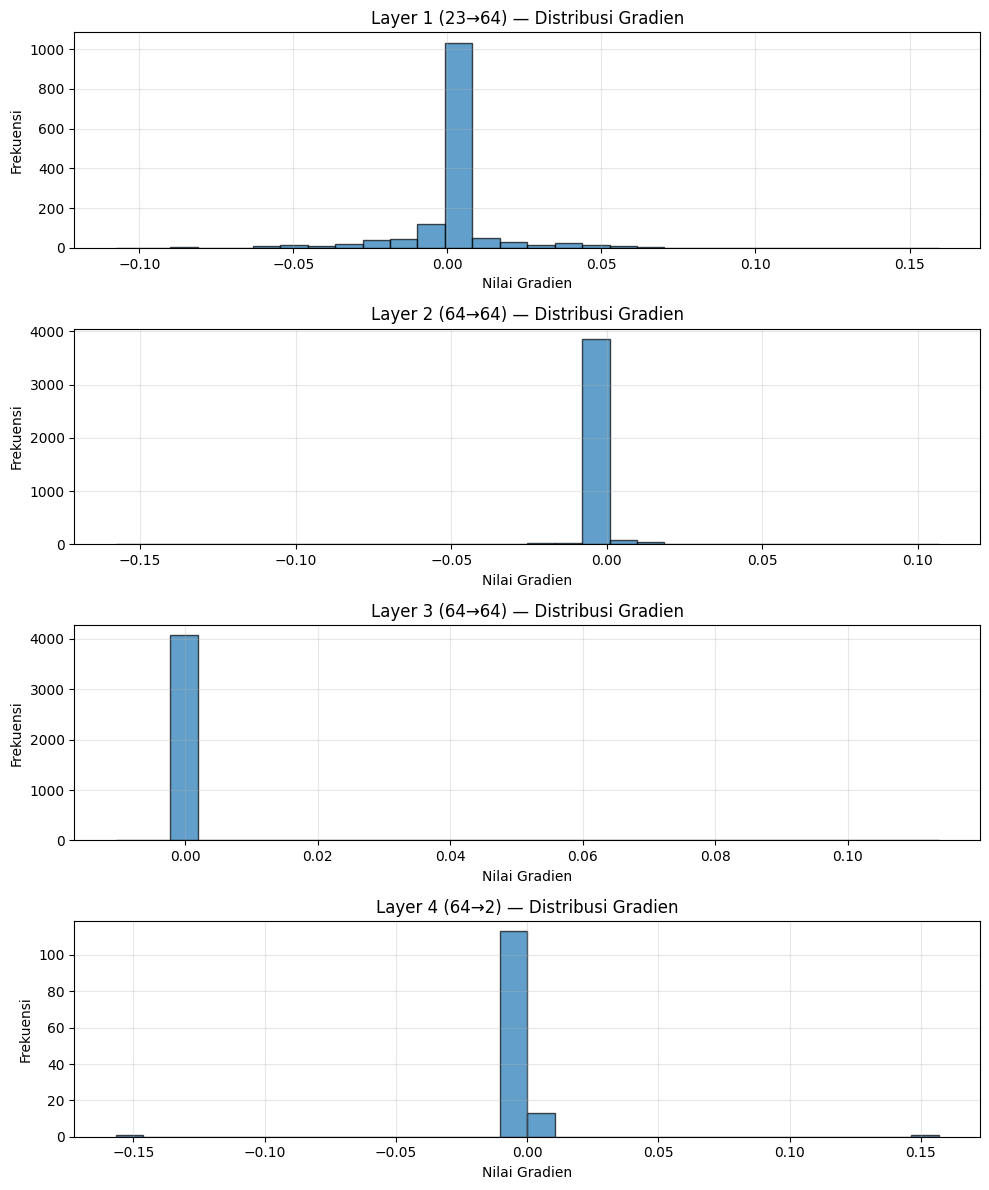


- Inisialisasi: Normal


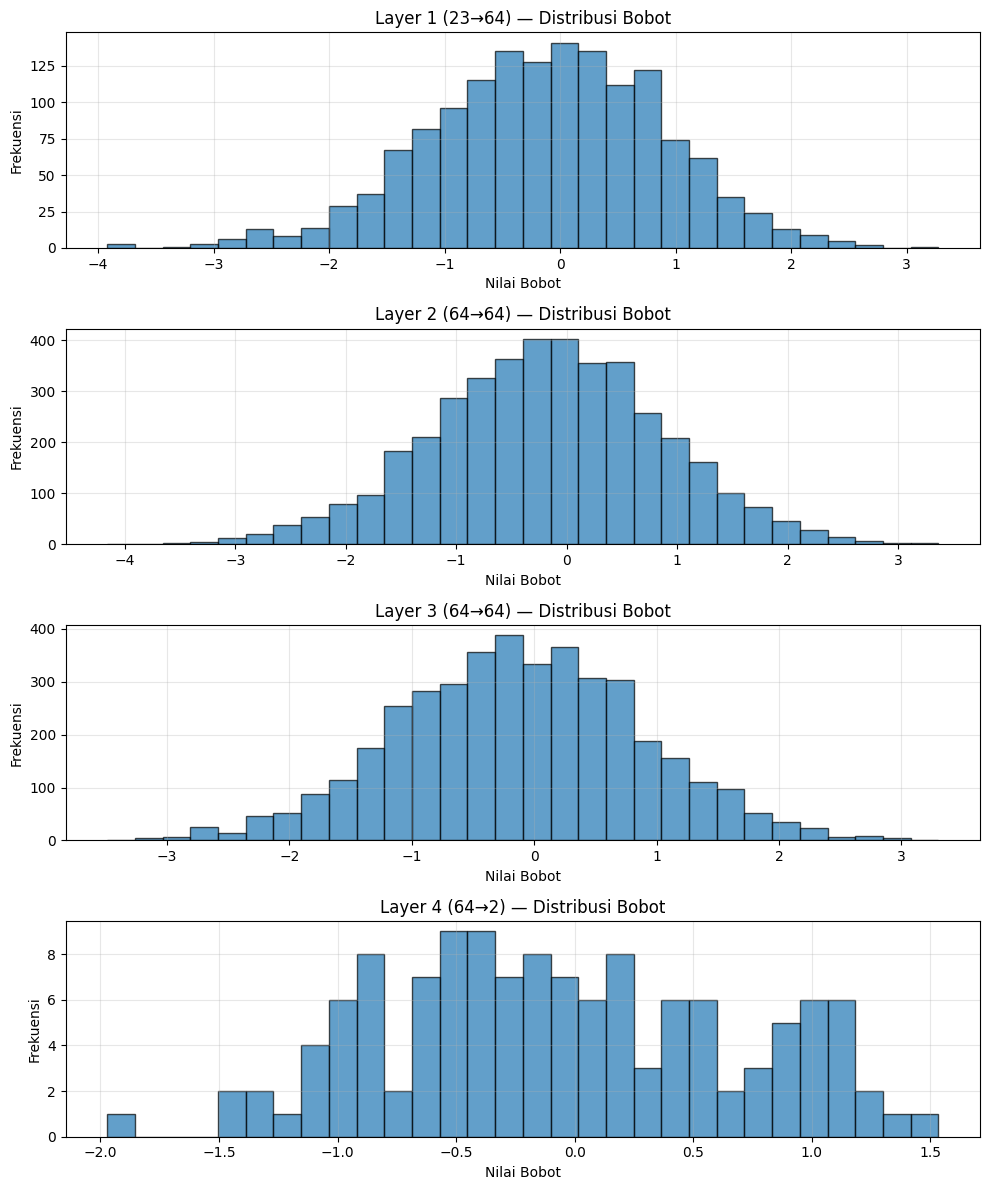

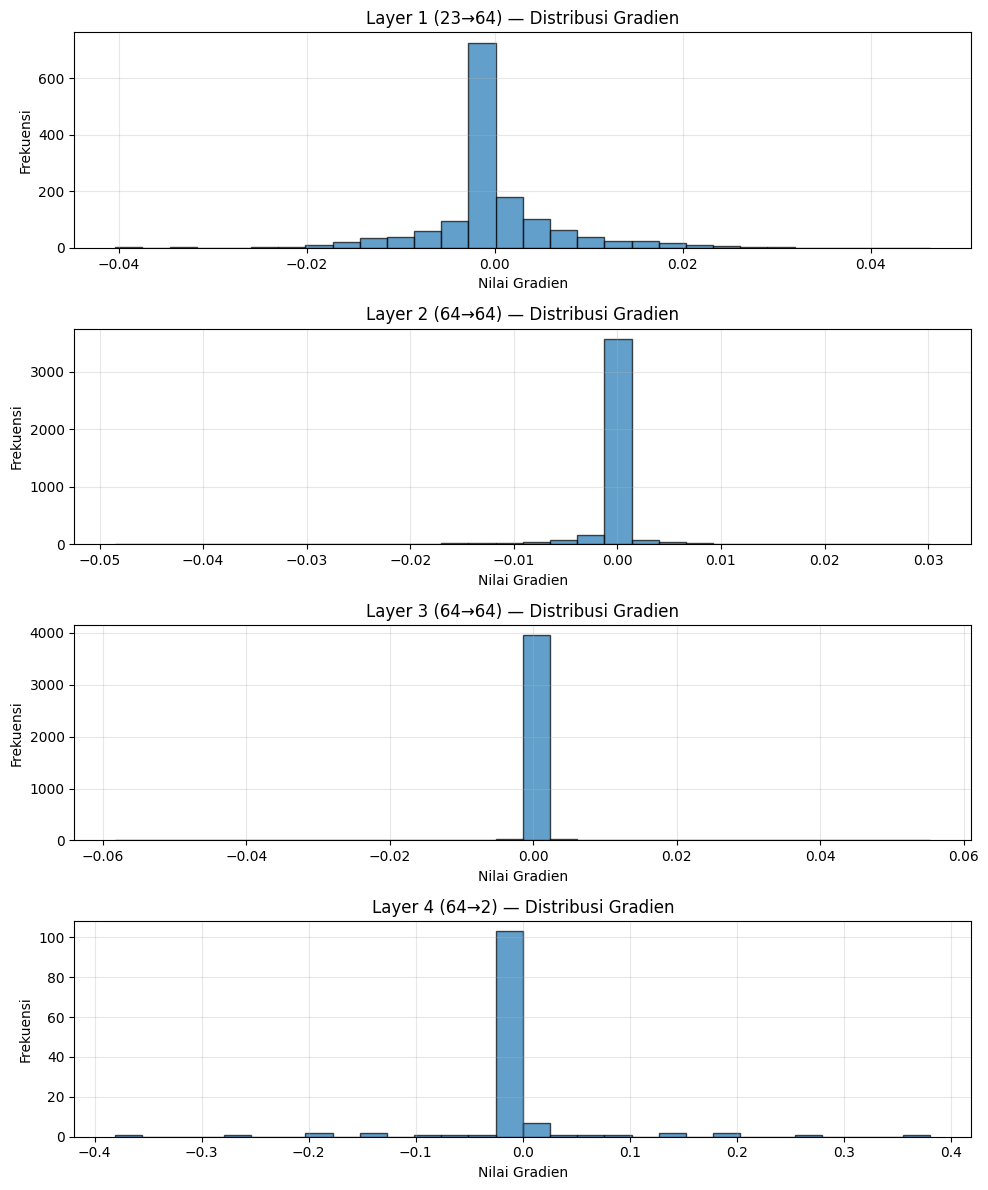


- Inisialisasi: Uniform


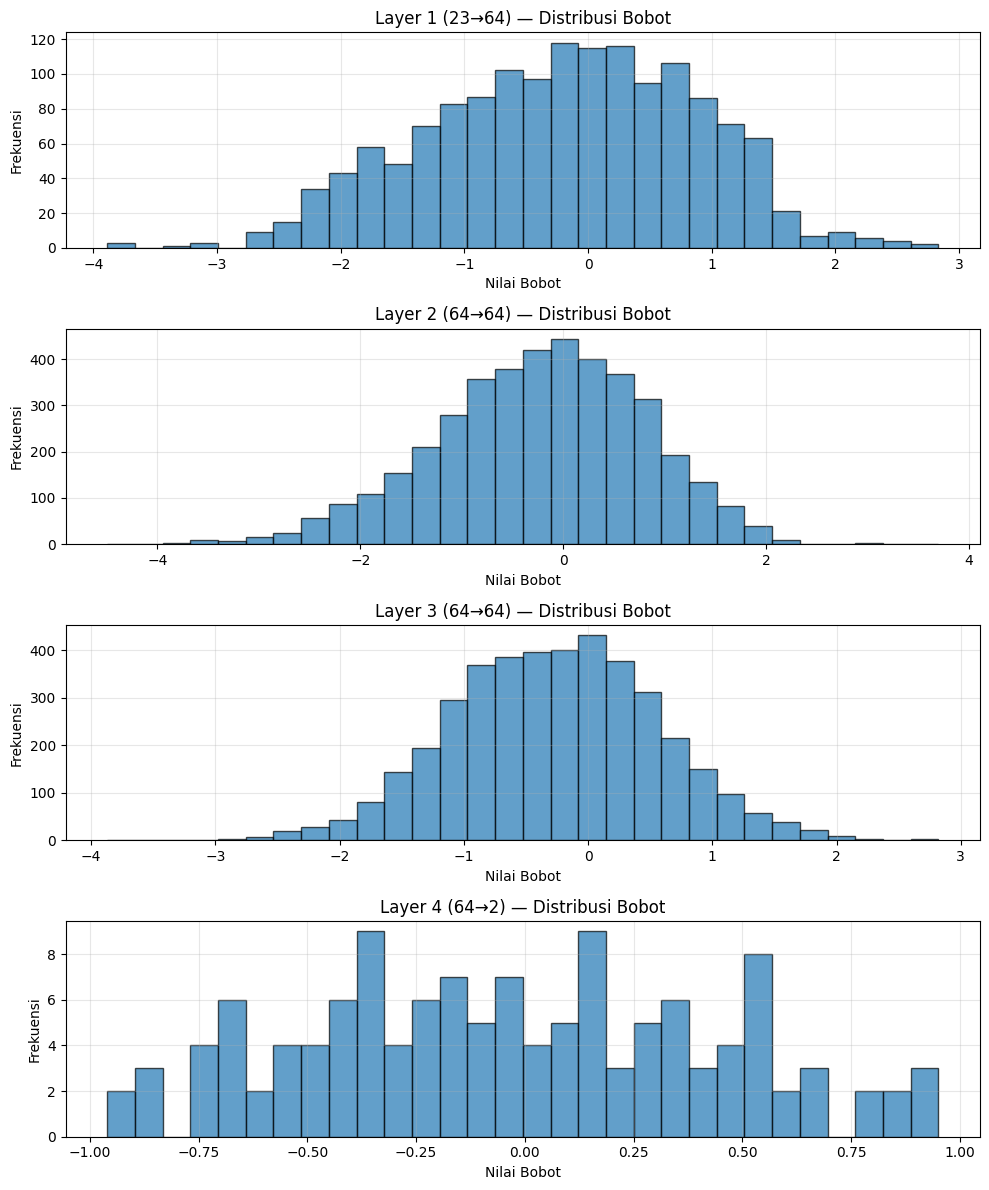

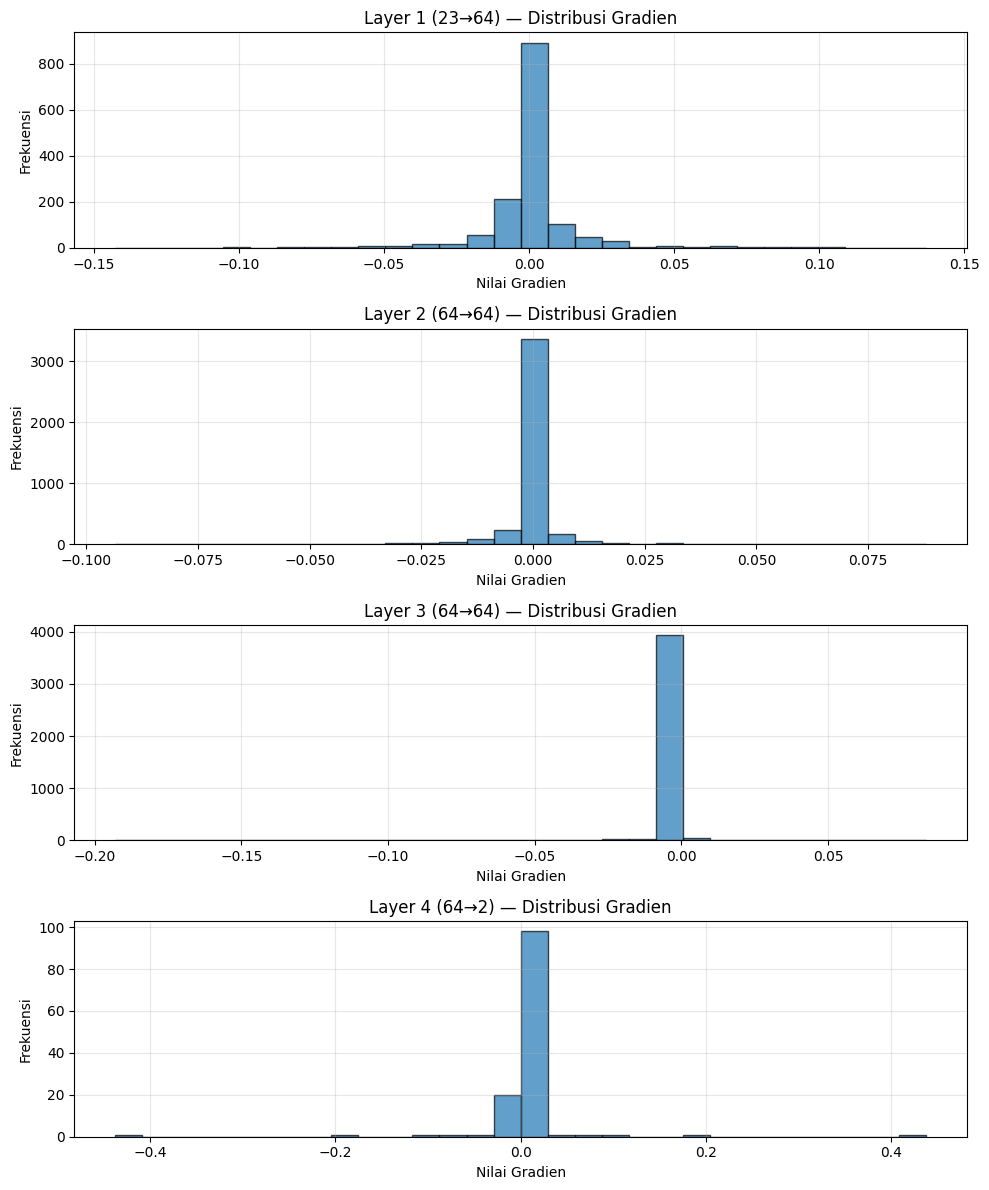


- Inisialisasi: Xavier


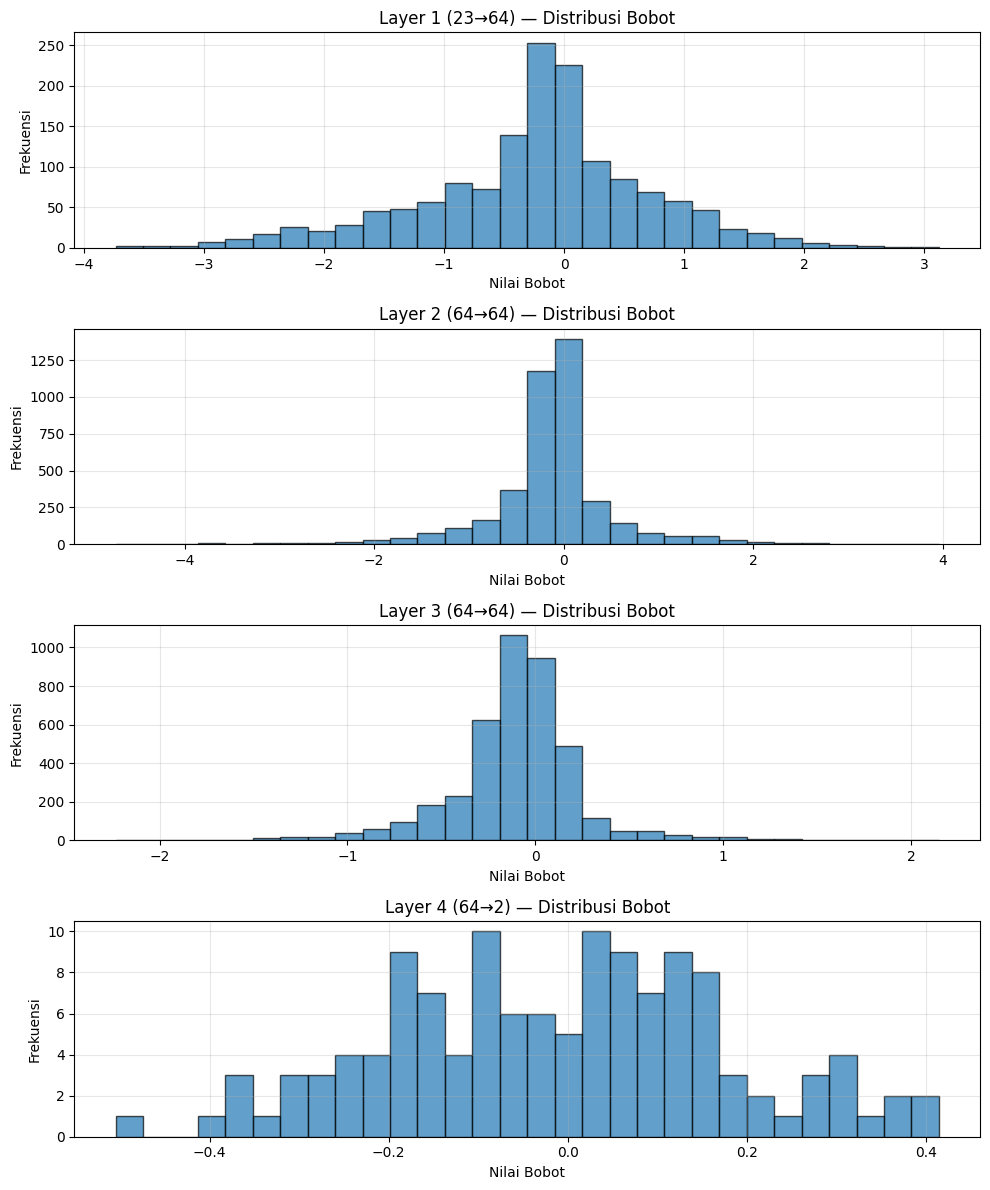

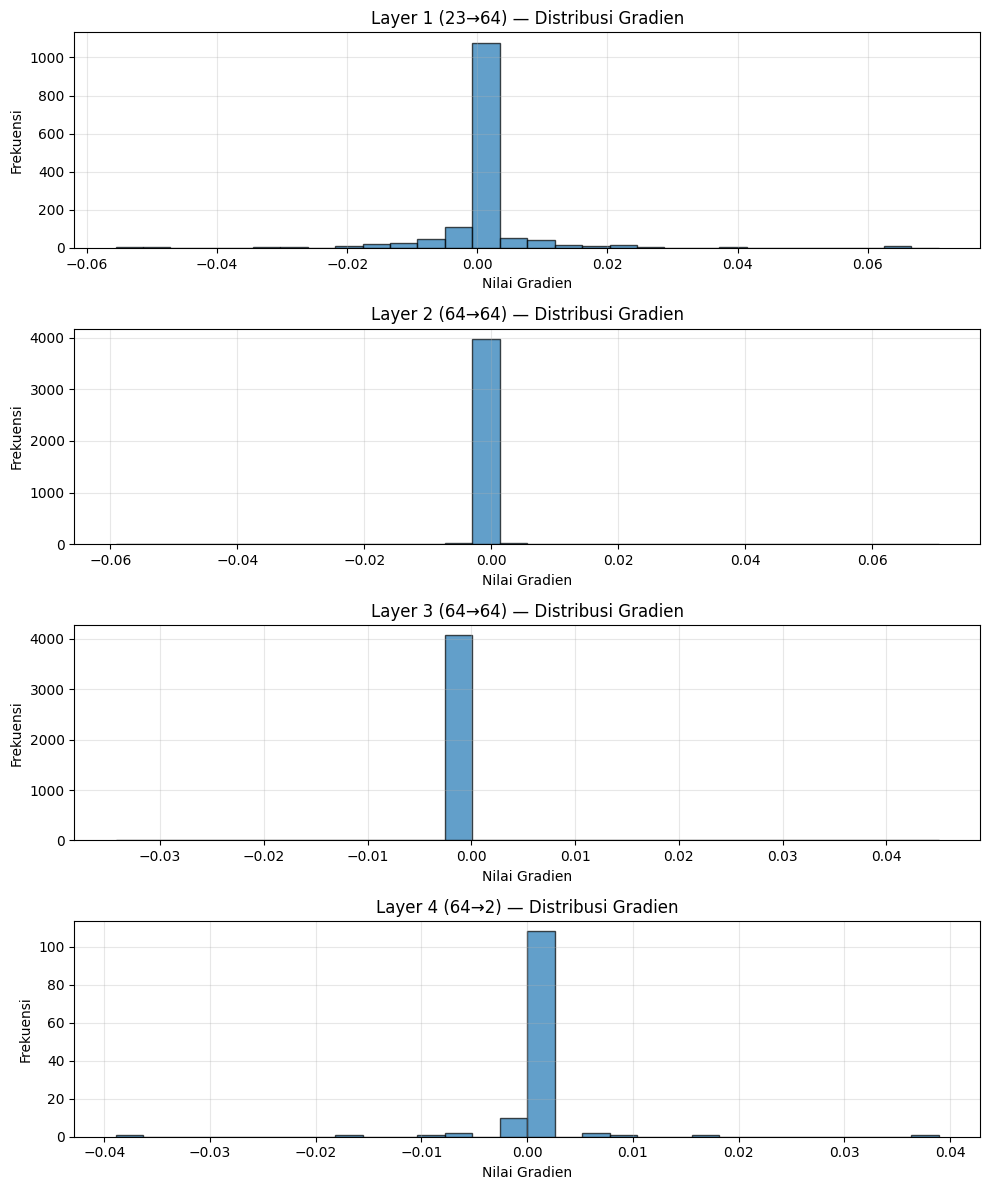


- Inisialisasi: Zero


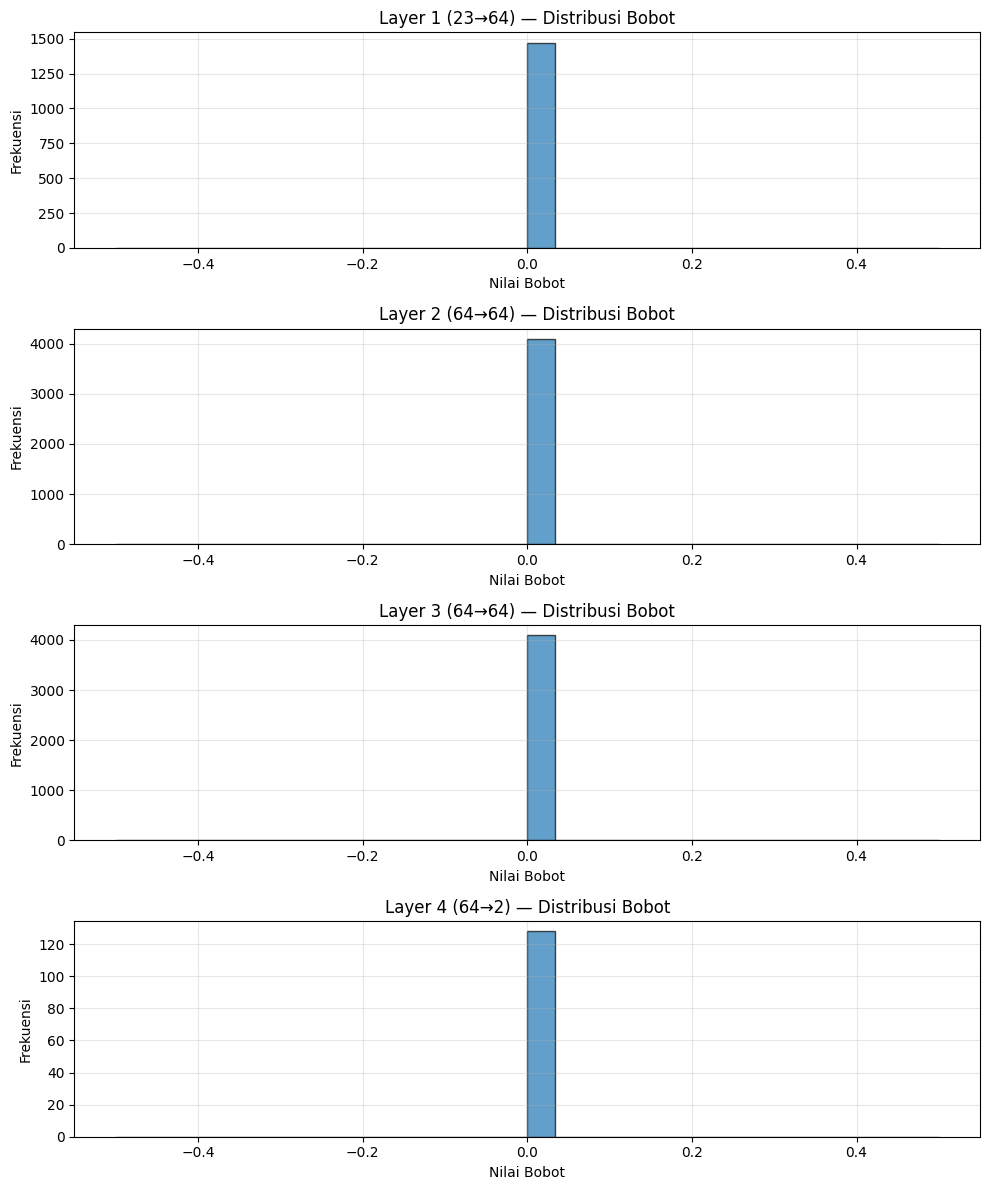

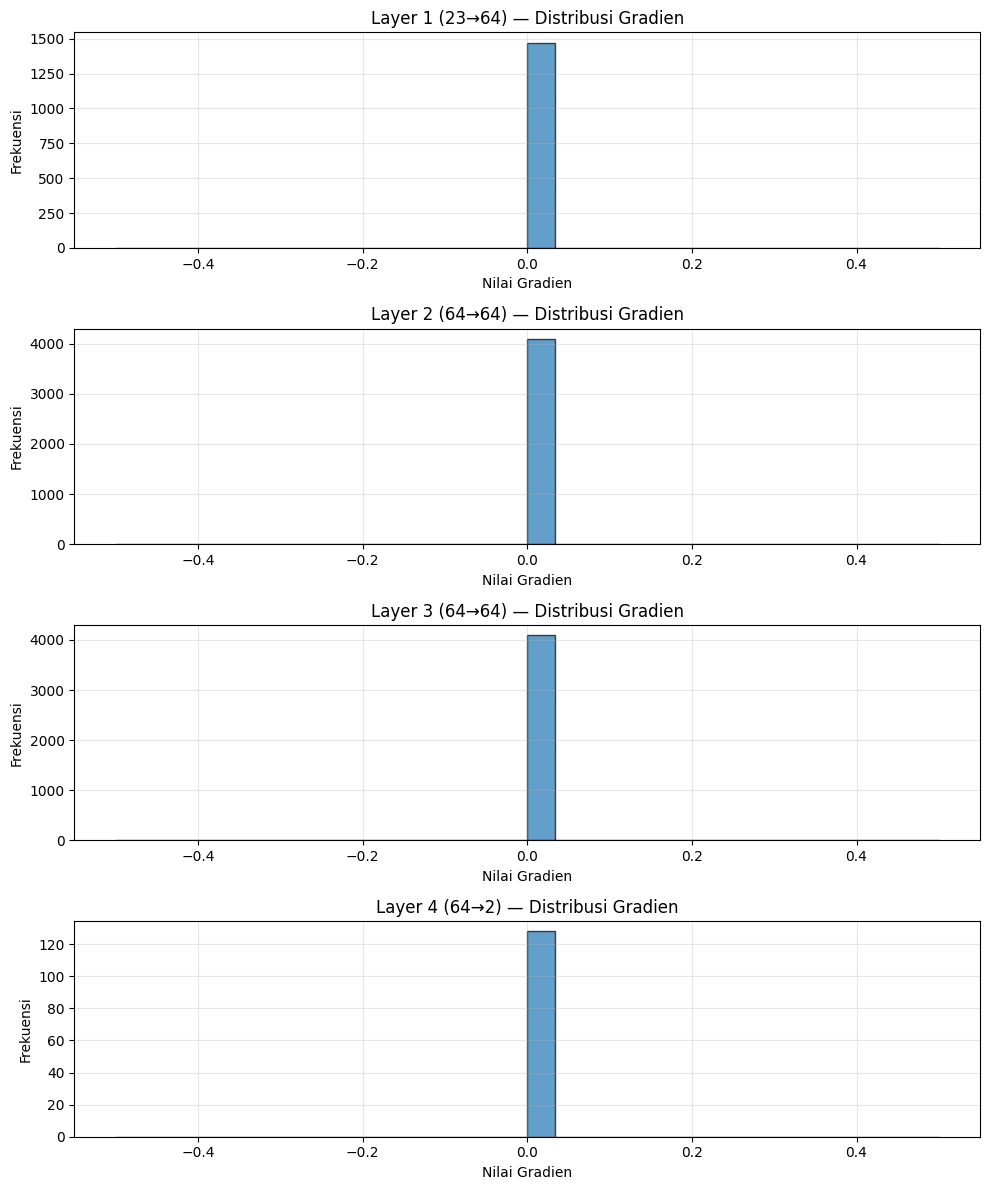

In [39]:
# distribusi bobot dan gradien
for name, model in init_models.items():
    print(f'\n- Inisialisasi: {name}')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

---
## 7. Bonus: RMSNorm — Normalisasi pada Hidden Layer

Eksperimen membandingkan model **tanpa normalisasi** vs **dengan RMSNorm** pada semua hidden layer.

Arsitektur: `[n_features, 64, 64, 64, n_classes]`, ReLU activation, CCE loss.

In [40]:
# load model
import os
SAVE_DIR_NORM_MODELS = '../models/bab7_norm/'
norm_models = {}
norm_results = []
if os.path.exists(SAVE_DIR_NORM_MODELS):
    for f in sorted(os.listdir(SAVE_DIR_NORM_MODELS)):
        if f.endswith('.pkl'):
            name = f.replace('.pkl', '')
            norm_models[name] = FFNN.load(os.path.join(SAVE_DIR_NORM_MODELS, f))
            print(f'  Loaded: {name}')
if norm_models:
    print(f'\nBerhasil load {len(norm_models)} model dari {SAVE_DIR_NORM_MODELS}')
    for name, model in norm_models.items():
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        norm_results.append(res)
else:
    print('Tidak ada model tersimpan, akan training dari awal.')

  Loaded: Dengan RMSNorm
  Loaded: Tanpa Normalisasi

Berhasil load 2 model dari ../models/bab7_norm/
Dengan RMSNorm:
  Train Accuracy: 0.8673
  Val Accuracy:   0.7140
  Test Accuracy:  0.7067
Tanpa Normalisasi:
  Train Accuracy: 0.8467
  Val Accuracy:   0.7140
  Test Accuracy:  0.7020


In [41]:
if not norm_models:
    norm_configs = {
        'Tanpa Normalisasi': None,
        'Dengan RMSNorm': True,  # RMSNorm pada semua layer
    }


    for name, norm_flag in norm_configs.items():
        print(f'\n- {name}')

        model = FFNN(
            layer_sizes=base_arch,
            activations=base_acts,
            loss='categorical_cross_entropy',
            init_method='he',
            init_params={'distribution': 'normal', 'seed': 42},
            normalization=norm_flag
        )
        model.train(X_train, y_train, X_val, y_val, batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0, optimizer='adam')
        norm_models[name] = model
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        norm_results.append(res)
else:
    print('Model Bab 7 (RMSNorm) sudah di-load, skip training.')

Model Bab 7 (RMSNorm) sudah di-load, skip training.


In [42]:
# save model
import os
SAVE_DIR_NORM_MODELS = '../models/bab7_norm/'
os.makedirs(SAVE_DIR_NORM_MODELS, exist_ok=True)
for name, model in norm_models.items():
    model.save(os.path.join(SAVE_DIR_NORM_MODELS, f'{name}.pkl'))
    print(f'  Saved: {name}')
print(f'Semua model Bab 7 (RMSNorm) disimpan di {SAVE_DIR_NORM_MODELS}')

  Saved: Dengan RMSNorm
  Saved: Tanpa Normalisasi
Semua model Bab 7 (RMSNorm) disimpan di ../models/bab7_norm/


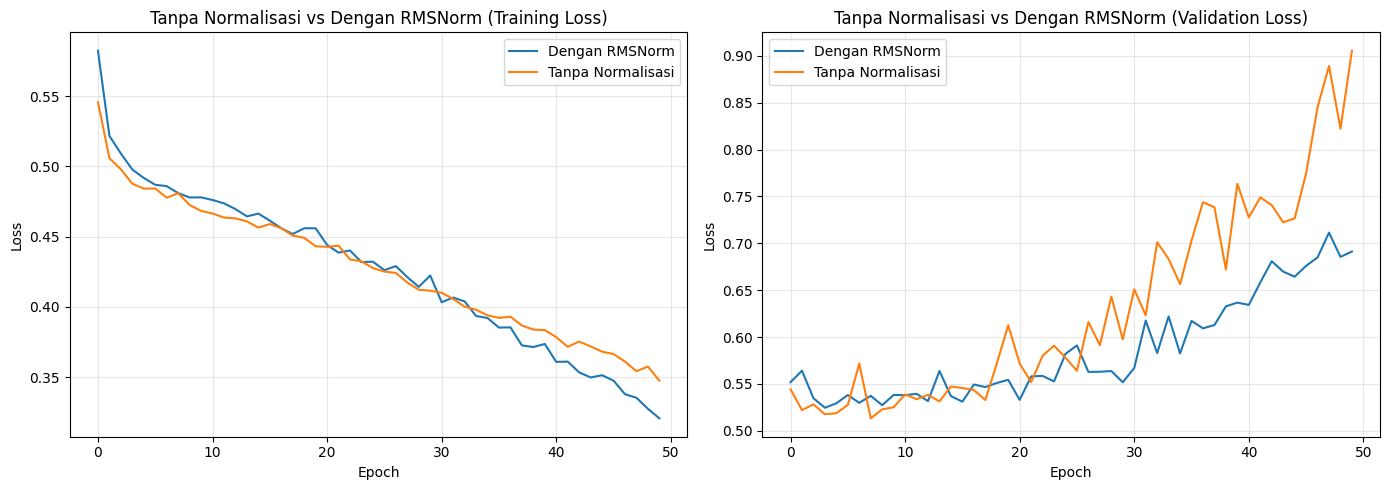

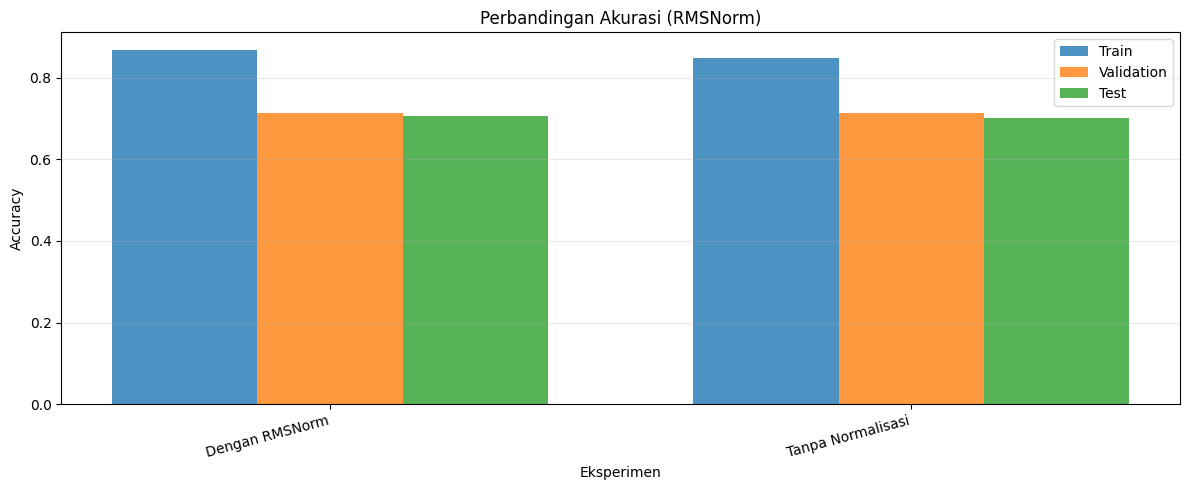

In [ ]:
# Perbandingan loss dan akurasi
compare_loss(norm_models, 'Tanpa Normalisasi vs Dengan RMSNorm')
compare_accuracy_bar(norm_results, 'Perbandingan Akurasi (RMSNorm)')


- Dengan RMSNorm


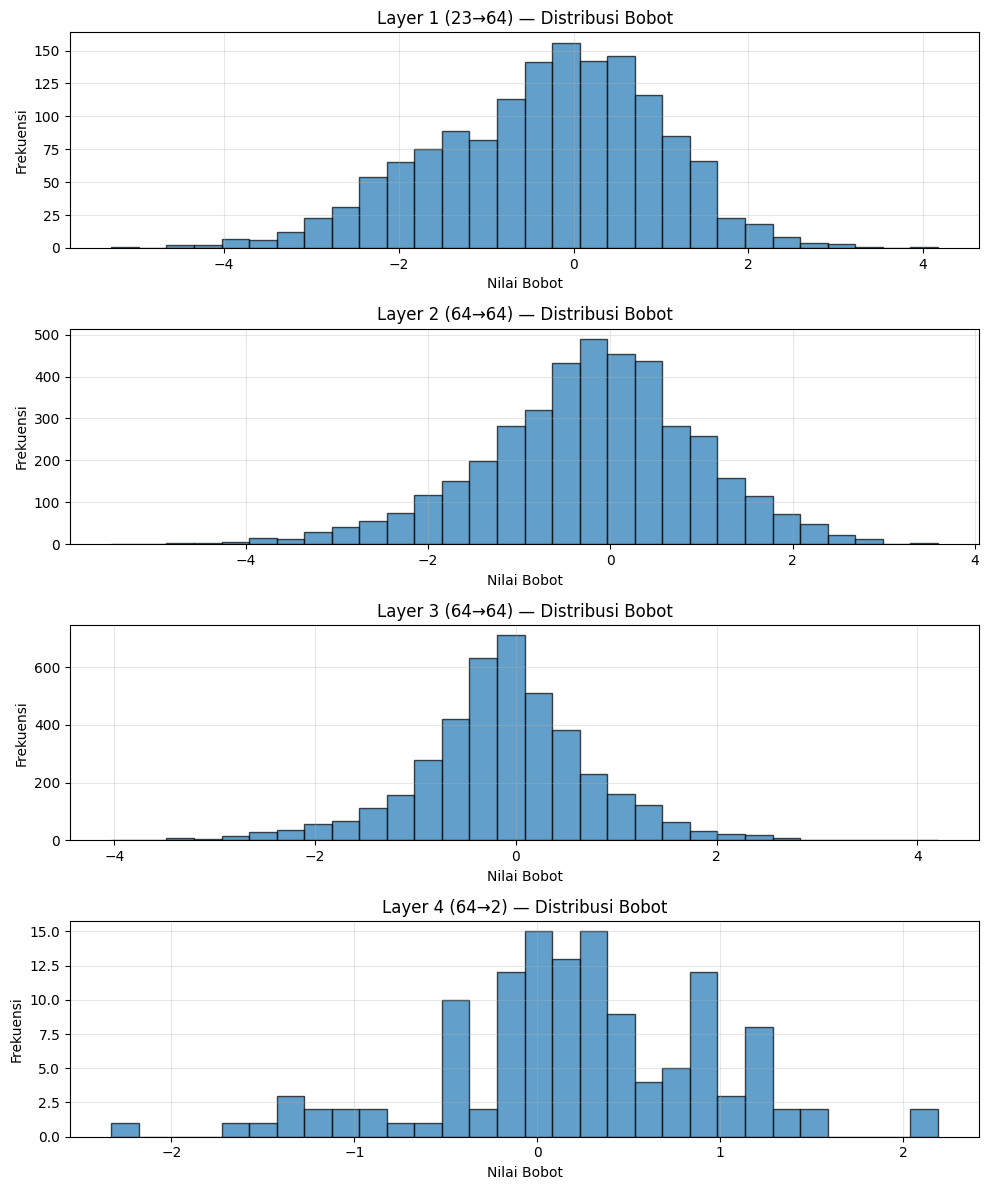

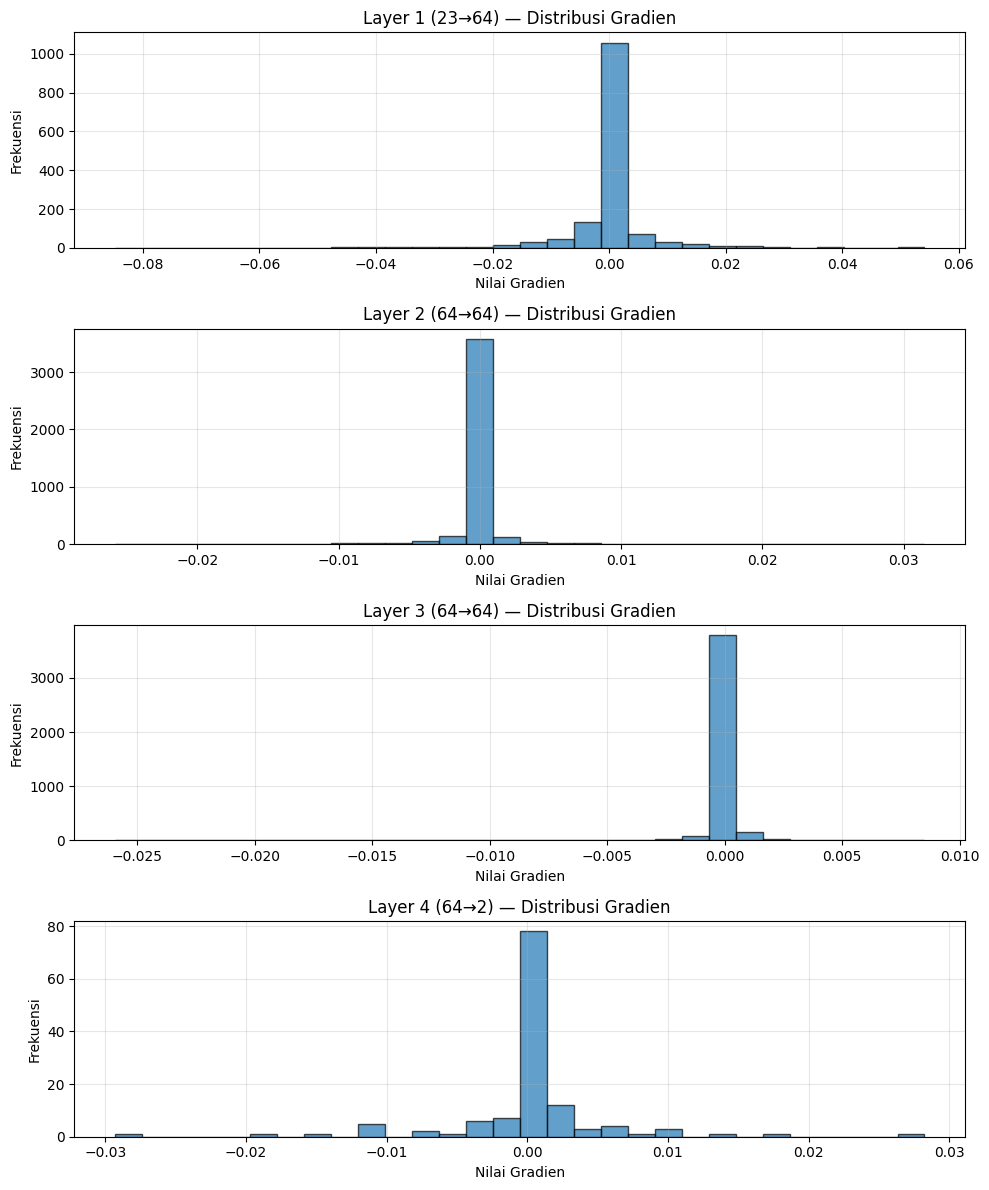


- Tanpa Normalisasi


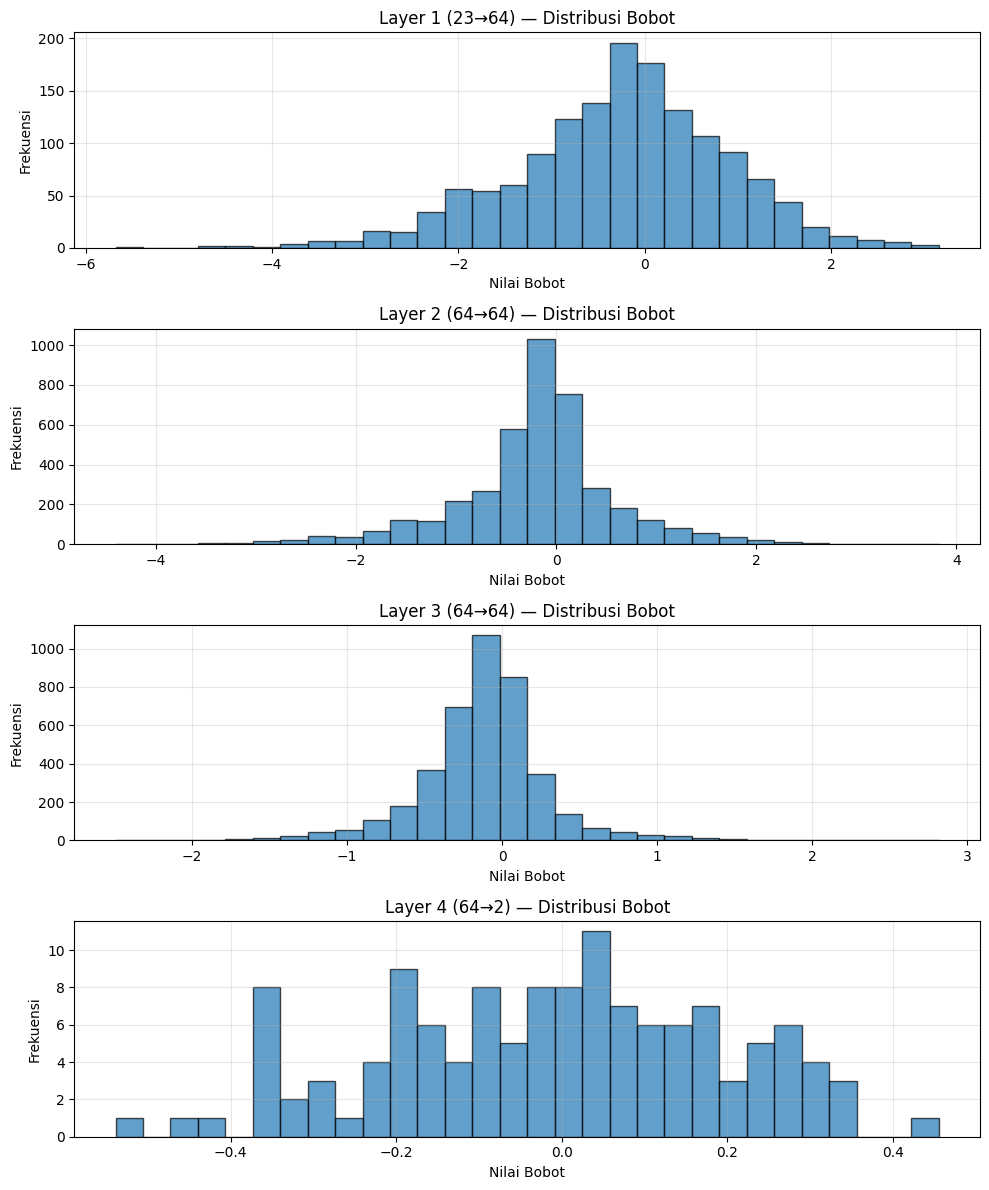

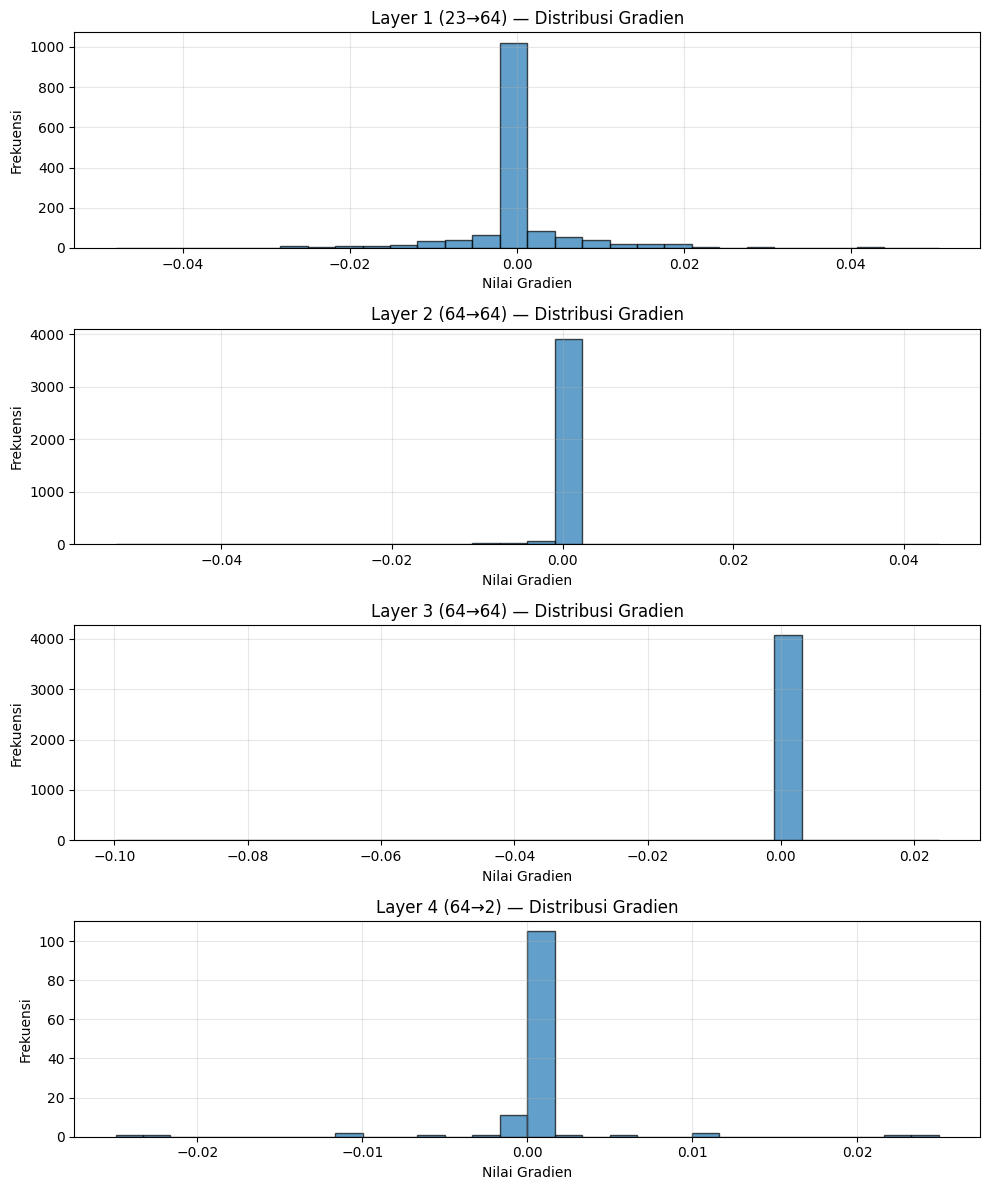

In [44]:
# Distribusi bobot dan gradien
for name, model in norm_models.items():
    print(f'\n- {name}')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

---
## 8. Perbandingan Optimizer: SGD vs Adam

Eksperimen ini melatih 2 model dengan arsitektur yang sama:
- **SGD**: menggunakan `optimizer='sgd'` pada `train()`
- **Adam**: menggunakan `optimizer='adam'`

In [45]:
# load model
import os
SAVE_DIR_OPTIMIZER_MODELS = '../models/bab8_optimizer/'
optimizer_models = {}
optimizer_results = []
if os.path.exists(SAVE_DIR_OPTIMIZER_MODELS):
    for f in sorted(os.listdir(SAVE_DIR_OPTIMIZER_MODELS)):
        if f.endswith('.pkl'):
            name = f.replace('.pkl', '')
            optimizer_models[name] = FFNN.load(os.path.join(SAVE_DIR_OPTIMIZER_MODELS, f))
            print(f'  Loaded: {name}')
if optimizer_models:
    print(f'\nBerhasil load {len(optimizer_models)} model dari {SAVE_DIR_OPTIMIZER_MODELS}')
    for name, model in optimizer_models.items():
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        optimizer_results.append(res)
else:
    print('Tidak ada model tersimpan, akan training dari awal.')

  Loaded: Adam
  Loaded: SGD (Gradient Descent)

Berhasil load 2 model dari ../models/bab8_optimizer/
Adam:
  Train Accuracy: 0.8417
  Val Accuracy:   0.7127
  Test Accuracy:  0.6947
SGD (Gradient Descent):
  Train Accuracy: 0.7821
  Val Accuracy:   0.7427
  Test Accuracy:  0.7327


In [46]:
if not optimizer_models:
    opt_arch = [n_features, 64, 64, 64, n_classes]
    opt_acts = ['relu', 'relu', 'relu', 'softmax']

    optimizer_configs = {
        'SGD (Gradient Descent)': {'optimizer': 'sgd'},
        'Adam': {'optimizer': 'adam'},
    }

    for name, train_kwargs in optimizer_configs.items():
        print(f'\n- Training {name}')

        model = FFNN(
            layer_sizes=opt_arch,
            activations=opt_acts,
            loss='categorical_cross_entropy',
            init_method='he',
            init_params={'distribution': 'normal', 'seed': 42}
        )

        model.train(
            X_train, y_train, X_val, y_val,
            batch_size=BATCH, learning_rate=LR, epochs=EPOCHS, verbose=0,
            **train_kwargs
        )

        optimizer_models[name] = model
        res = print_results(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
        optimizer_results.append(res)
else:
    print('Model Bab 8 (Optimizer) sudah di-load, skip training.')

Model Bab 8 (Optimizer) sudah di-load, skip training.


In [47]:
# save model
import os
SAVE_DIR_OPTIMIZER_MODELS = '../models/bab8_optimizer/'
os.makedirs(SAVE_DIR_OPTIMIZER_MODELS, exist_ok=True)
for name, model in optimizer_models.items():
    model.save(os.path.join(SAVE_DIR_OPTIMIZER_MODELS, f'{name}.pkl'))
    print(f'  Saved: {name}')
print(f'Semua model Bab 8 (Optimizer) disimpan di {SAVE_DIR_OPTIMIZER_MODELS}')

  Saved: Adam
  Saved: SGD (Gradient Descent)
Semua model Bab 8 (Optimizer) disimpan di ../models/bab8_optimizer/


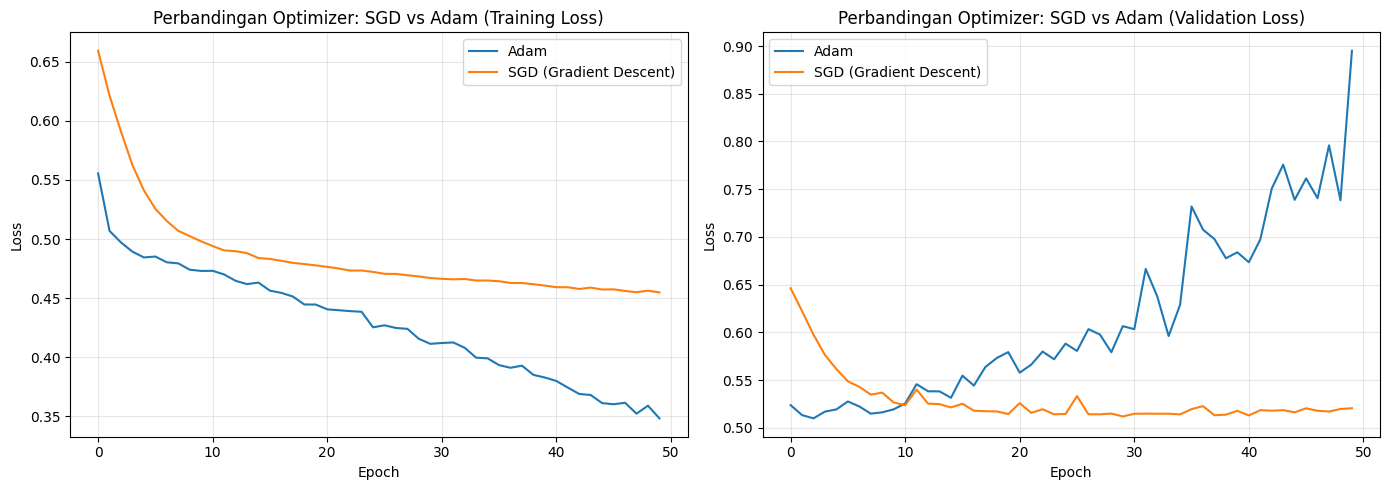

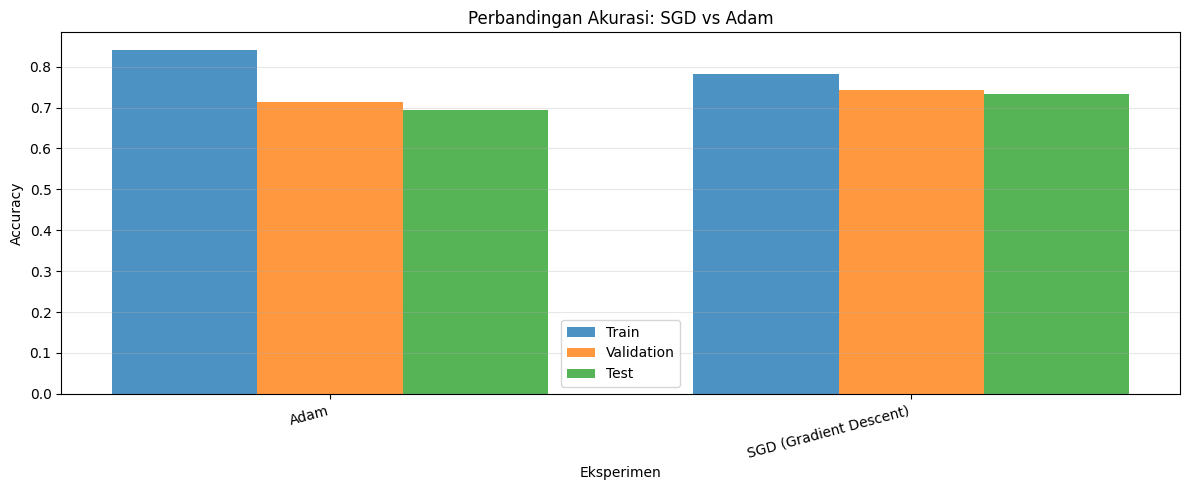

,Eksperimen,Train Acc,Val Acc,Test Acc
0,Adam,0.841714,0.712667,0.694667
1,SGD (Gradient Descent),0.782143,0.742667,0.732667


In [48]:
# Perbandingan loss dan akurasi
compare_loss(optimizer_models, 'Perbandingan Optimizer: SGD vs Adam')
compare_accuracy_bar(optimizer_results, 'Perbandingan Akurasi: SGD vs Adam')

optimizer_df = pd.DataFrame(optimizer_results)
optimizer_df.columns = ['Eksperimen', 'Train Acc', 'Val Acc', 'Test Acc']
optimizer_df

---
## Ringkasan Hasil

In [49]:
all_results = []
all_results.extend([{**r, 'Kategori': 'Width'} for r in width_results])
all_results.extend([{**r, 'Kategori': 'Depth'} for r in depth_results])
all_results.extend([{**r, 'Kategori': 'Aktivasi'} for r in act_results])
all_results.extend([{**r, 'Kategori': 'Learning Rate'} for r in lr_results])
all_results.extend([{**r, 'Kategori': 'Regularisasi'} for r in reg_results])
all_results.extend([{**r, 'Kategori': 'Inisialisasi'} for r in init_results])
all_results.extend([{**r, 'Kategori': 'RMSNorm'} for r in norm_results])
all_results.extend([{**r, 'Kategori': 'Optimizer'} for r in optimizer_results])

summary_df = pd.DataFrame(all_results)
summary_df.columns = ['Eksperimen', 'Train Acc', 'Val Acc', 'Test Acc', 'Kategori']
summary_df = summary_df[['Kategori', 'Eksperimen', 'Train Acc', 'Val Acc', 'Test Acc']]
summary_df

,Kategori,Eksperimen,Train Acc,Val Acc,Test Acc
0,Width,Width=128,0.873857,0.726000,0.701333
1,Width,Width=16,0.780714,0.729333,0.726000
2,Width,Width=64,0.842143,0.720667,0.708000
3,Depth,Depth=1,0.816286,0.724667,0.713333
4,Depth,Depth=3,0.825571,0.720667,0.700667
5,Depth,Depth=5,0.810429,0.732667,0.714000
6,Aktivasi,elu,0.816429,0.732000,0.708667
7,Aktivasi,linear,0.806857,0.730000,0.715333
8,Aktivasi,relu,0.854143,0.700667,0.712000
9,Aktivasi,sigmoid,0.859000,0.705333,0.681333
